# 02 · Reproduce the paper and appendix

Run all cells in order. This notebook reads `scoring_output.zip`; it does not need the restricted texts, API keys, or notebook 01 to be rerun.

Each figure and table appears below in manuscript order. A run also saves the six figure PDFs and eleven table CSVs in `results/`.

Dependencies: Python 3.11+, numpy, pandas, scipy, scikit-learn, statsmodels, matplotlib, and Pillow.

In [1]:
from pathlib import Path
import os,sys,json,zipfile,tempfile,shutil,warnings
import numpy as np,pandas as pd
from IPython.display import display,Image

PACKAGE_DIR = None  # Set this only when launching outside the replication folder.
start = Path.cwd()
location = start if (start/'scoring_output.zip').is_file() else globals().get('PACKAGE',start)
PACKAGE = Path(PACKAGE_DIR or os.environ.get('WORDS_TRAVEL_PACKAGE') or location).resolve()
if not (PACKAGE/'scoring_output.zip').is_file():
    raise FileNotFoundError('Open this notebook from the replication folder or set PACKAGE_DIR.')
# Keep implementation files and intermediate calculations out of the reader's folder.
_work = tempfile.TemporaryDirectory(prefix='words_travel_')
ROOT = Path(_work.name)
for folder in ['input','code','derived','results','figures']:(ROOT/folder).mkdir()
expected={'statements.csv','ratings.csv','pair_ratings.csv','claims.csv','phrase_overlap.csv','reconstruction.csv','reconstruction_targets.csv'}
with zipfile.ZipFile(PACKAGE/'scoring_output.zip') as archive:
    if set(archive.namelist())!=expected:raise ValueError('The scoring output must contain the seven documented CSV files.')
    for name in sorted(expected):(ROOT/'input'/name).write_bytes(archive.read(name))
# The analysis never makes model calls or network requests.
import urllib.request
urllib.request.urlopen=lambda *a,**k: (_ for _ in ()).throw(RuntimeError('Analysis is offline.'))
os.environ['MPLCONFIGDIR']=str(ROOT/'matplotlib')
os.chdir(ROOT);sys.path.insert(0,str(ROOT/'code'))
for name in ['data','definitions','estimation','analysis','figures','exhibits','identification','verification']:sys.modules.pop(name,None)
warnings.filterwarnings('ignore',category=pd.errors.PerformanceWarning)
# Some NumPy/Apple Accelerate builds report false matmul warnings for finite results.
# Suppress only these backend messages; finite-result checks remain active.
blas = getattr(np.__config__,'CONFIG',{}).get('Build Dependencies',{}).get('blas',{}).get('name','')
if sys.platform == 'darwin' and blas == 'accelerate' and np.__version__.startswith('2.2.'):
    warnings.filterwarnings('ignore',message=r'(divide by zero|overflow|invalid value) encountered in matmul',
                            category=RuntimeWarning)
pd.set_option('display.max_rows',60)
print('Loaded saved scoring outputs. No raw texts or API calls are required.')

Loaded saved scoring outputs. No raw texts or API calls are required.


## Calculation functions
These cells contain the complete estimation and plotting code. They are collapsed by default to keep the results easy to follow.

In [2]:
%%writefile code/definitions.py
"""Fixed economic definitions and country classifications; no fitted results."""
SOURCE_OFFICIAL_ENGLISH = {'AU','CA','SZ','ECB','GM','GH','IS','IN','KE','LS','LR','MW','NZ','NG','PK','PH','RW','SL','ZA','UG','GB','US','ZM'}
ADVANCED = {'AU', 'CA', 'CH', 'CZ', 'ECB', 'GB', 'IL', 'IS', 'JP', 'KR', 'NO', 'NZ', 'SE', 'TW', 'US'}
ENGLISH_ORIGINAL = {'US', 'GB', 'CA', 'AU', 'NZ', 'ECB'}
INFLATION_TARGETERS = {'AU', 'BR', 'CA', 'CL', 'CO', 'CZ', 'GB', 'GH', 'HU', 'ID', 'IL', 'IN', 'IS', 'KR', 'MX', 'NZ', 'NO', 'PH', 'PL', 'SE', 'TH', 'TR', 'ZA'}
ISO2_TO_ISO3 = {'AR': 'ARG', 'AU': 'AUS', 'BR': 'BRA', 'CA': 'CAN', 'CH': 'CHE', 'CL': 'CHL', 'CO': 'COL', 'CZ': 'CZE', 'EG': 'EGY', 'GB': 'GBR', 'GH': 'GHA', 'GM': 'GMB', 'HU': 'HUN', 'ID': 'IDN', 'IL': 'ISR', 'IN': 'IND', 'IS': 'ISL', 'JP': 'JPN', 'KE': 'KEN', 'KR': 'KOR', 'KZ': 'KAZ', 'LK': 'LKA', 'LR': 'LBR', 'LS': 'LSO', 'MD': 'MDA', 'MN': 'MNG', 'MW': 'MWI', 'MX': 'MEX', 'MY': 'MYS', 'MZ': 'MOZ', 'NG': 'NGA', 'NO': 'NOR', 'NZ': 'NZL', 'PH': 'PHL', 'PK': 'PAK', 'PL': 'POL', 'RW': 'RWA', 'SE': 'SWE', 'SL': 'SLE', 'SZ': 'SWZ', 'TH': 'THA', 'TJ': 'TJK', 'TR': 'TUR', 'TW': 'TWN', 'UA': 'UKR', 'UG': 'UGA', 'US': 'USA', 'UZ': 'UZB', 'ZA': 'ZAF', 'ZM': 'ZMB'}
COUNTRY_NAME = {'AR': 'Argentina', 'AU': 'Australia', 'BR': 'Brazil', 'CA': 'Canada', 'CH': 'Switzerland', 'CL': 'Chile', 'CO': 'Colombia', 'CZ': 'Czechia', 'ECB': 'Euro area', 'EG': 'Egypt', 'GB': 'United Kingdom', 'GH': 'Ghana', 'GM': 'Gambia', 'HU': 'Hungary', 'ID': 'Indonesia', 'IL': 'Israel', 'IN': 'India', 'IS': 'Iceland', 'JP': 'Japan', 'KE': 'Kenya', 'KR': 'Korea', 'KZ': 'Kazakhstan', 'LK': 'Sri Lanka', 'LR': 'Liberia', 'LS': 'Lesotho', 'MD': 'Moldova', 'MN': 'Mongolia', 'MW': 'Malawi', 'MX': 'Mexico', 'MY': 'Malaysia', 'MZ': 'Mozambique', 'NG': 'Nigeria', 'NO': 'Norway', 'NZ': 'New Zealand', 'PH': 'Philippines', 'PK': 'Pakistan', 'PL': 'Poland', 'RW': 'Rwanda', 'SE': 'Sweden', 'SL': 'Sierra Leone', 'SZ': 'Eswatini', 'TH': 'Thailand', 'TJ': 'Tajikistan', 'TR': 'Turkey', 'TW': 'Taiwan', 'UA': 'Ukraine', 'UG': 'Uganda', 'US': 'United States', 'UZ': 'Uzbekistan', 'ZA': 'South Africa', 'ZM': 'Zambia'}
CONCEPTS = ['activity_outlook', 'inflation_outlook', 'hawkish_reaction', 'supply_narrative', 'uncertainty', 'fx_pressure', 'financial_stability']
HF_CONCEPTS = CONCEPTS[:5] + ['disagreement']
LABELS = {'activity_outlook': 'Activity outlook', 'inflation_outlook': 'Inflation outlook', 'hawkish_reaction': 'Hawkish language', 'supply_narrative': 'Supply attribution', 'uncertainty': 'Uncertainty', 'fx_pressure': 'Exchange-rate pressure', 'financial_stability': 'Financial stability', 'disagreement': 'Disagreement'}
LM_NEG = {'loss', 'losses', 'decline', 'declined', 'negative', 'default', 'litigation', 'impairment', 'volatile', 'weakness', 'adverse', 'failure', 'unfavorable', 'downturn', 'recession', 'crisis', 'risk', 'risks', 'uncertain', 'uncertainty', 'deterioration', 'shortage'}
LM_POS = {'gain', 'gains', 'improve', 'improved', 'strong', 'strength', 'profitable', 'opportunity', 'favorable', 'stable', 'confidence', 'expansion', 'robust', 'solid', 'resilient'}
HAWKISH_WORDS = {'tighten', 'tightening', 'restrictive', 'hike', 'hikes', 'hawkish', 'firming', 'raise', 'raising', 'increase', 'increasing', 'higher', 'hot', 'overheating', 'remove', 'accommodation', 'restrict', 'restricting'}
DOVISH_WORDS = {'ease', 'easing', 'accommodative', 'cut', 'cuts', 'dovish', 'lower', 'decrease', 'decreasing', 'patient', 'stimulus', 'supportive', 'loosen', 'loosening'}


Writing code/definitions.py


In [3]:
%%writefile code/data.py
from pathlib import Path
import json
import numpy as np
import pandas as pd
from definitions import *
ROOT=Path(__file__).resolve().parents[1]
def read_jsonl(path):
    with Path(path).open(encoding='utf8') as f:return [json.loads(line) for line in f if line.strip()]
def z(s):
    sd=s.std(ddof=0)
    return (s-s.mean())/sd if pd.notna(sd) and sd>1e-12 else s*0


Writing code/data.py


In [4]:
%%writefile code/estimation.py
"""Fresh OLS/WLS, multiway inference, contrasts and explicit unidentified terms."""
import numpy as np
import pandas as pd
from scipy import stats, linalg
from statsmodels.stats.multitest import multipletests
from itertools import combinations

def bh(df,groups,p='p_value',q='q_value',family_size=None):
    df=df.copy();df[q]=np.nan
    chunks=df.groupby(groups,dropna=False) if groups else [(None,df)]
    for _,g in chunks:
        idx=g.index[g[p].notna()];v=df.loc[idx,p].to_numpy()
        if not len(v):continue
        m=family_size or len(g)
        df.loc[idx,q]=multipletests(np.r_[v,np.ones(max(0,m-len(v)))],method='fdr_bh')[1][:len(v)]
    return df
def cluster_meat(scores,labels):
    code=pd.factorize(labels)[0];n=code.max()+1
    sums=np.zeros((n,scores.shape[1]));np.add.at(sums,code,scores)
    return sums.T@sums,n
def fit(d,y,x,fe=('country','year'),clusters=('country','fed_date'),weight=None,contrasts=None):
    needed=list(dict.fromkeys([y,*x,*fe,*clusters]+([weight] if weight else [])))
    a=d[needed].replace([np.inf,-np.inf],np.nan).dropna().copy()
    meta=dict(n=len(a),n_countries=a.country.nunique() if 'country' in a else np.nan)
    if len(a)<10:
        names=list(x)+list((contrasts or {}).keys())
        return [dict(term=t,estimate=np.nan,std_error=np.nan,p_value=np.nan,ci_low=np.nan,ci_high=np.nan,
                     status='insufficient_observations',covariance_valid=False,n_events=a[clusters[1]].nunique() if len(clusters)>1 else np.nan,
                     df_t=np.nan,rank=0,parameters=0,cluster_dimensions=';'.join(clusters),r_squared=np.nan,**meta) for t in names],None
    varying=[c for c in x if a[c].std(ddof=0)>1e-12 or (c=='intercept' and a[c].eq(1).all())]
    constant=[] if 'intercept' in varying else [pd.DataFrame({'const':np.ones(len(a))},index=a.index)]
    X=pd.concat([*constant,a[varying].astype(float),*[pd.get_dummies(a[c],prefix=c,drop_first=True,dtype=float) for c in fe]],axis=1)
    # Fit in full design to retain finite sample cluster correction for absorbed effects.
    w=np.ones(len(a)) if weight is None else a[weight].to_numpy(float)
    xx=X.to_numpy(float)*np.sqrt(w)[:,None];yy=a[y].to_numpy(float)*np.sqrt(w)
    beta,_,rank,_=linalg.lstsq(xx,yy,lapack_driver='gelsy');res=yy-xx@beta
    bread=linalg.pinvh(xx.T@xx);scores=xx*res[:,None]
    cov=np.zeros_like(bread);cluster_counts=[]
    if clusters:
        for size in range(1,len(clusters)+1):
            for subset in combinations(clusters,size):
                labels=pd.MultiIndex.from_frame(a[list(subset)])
                meat,g=cluster_meat(scores,labels)
                if size==1:cluster_counts.append(g)
                factor=g/max(1,g-1)*(len(a)-1)/max(1,len(a)-X.shape[1])
                cov+=(-1)**(size+1)*factor*bread@meat@bread
        dof=min(cluster_counts)-1
    else:
        h=np.sum(xx*(xx@bread),axis=1);s=xx*(res/np.clip(1-h,1e-8,None))[:,None]
        cov=bread@s.T@s@bread;dof=np.inf
    if not (np.isfinite(beta).all() and np.isfinite(cov).all() and np.isfinite(res).all()):
        raise ArithmeticError('Non-finite regression calculation; no result accepted')
    weighted_mean=np.average(a[y].to_numpy(float),weights=w)
    tss=np.sum(w*(a[y].to_numpy(float)-weighted_mean)**2)
    meta.update(n_events=cluster_counts[1] if len(cluster_counts)>1 else np.nan,df_t=dof,rank=int(rank),parameters=X.shape[1],cluster_dimensions=';'.join(clusters),r_squared=1-res@res/max(1e-30,tss))
    rows=[]
    def record(name,vec,estimable=True):
        b=float(vec@beta);variance=float(vec@cov@vec);valid=variance>0 and estimable and dof>0
        se=np.sqrt(variance) if valid else np.nan
        critical=stats.t.ppf(.975,dof) if np.isfinite(dof) else stats.norm.ppf(.975)
        pv=2*stats.t.sf(abs(b/se),dof) if valid else np.nan
        rows.append(dict(term=name,estimate=b if estimable else np.nan,std_error=se,p_value=pv,ci_low=b-critical*se,ci_high=b+critical*se,
            status='identified' if estimable else 'unidentified',covariance_valid=valid,**meta))
    for term in x:
        vec=np.zeros(len(beta))
        if term in X:vec[X.columns.get_loc(term)]=1
        record(term,vec,term in X and rank==X.shape[1])
    for name,weights in (contrasts or {}).items():
        vec=np.zeros(len(beta));ok=all(t in X for t in weights)
        if ok:
            for t,v in weights.items():vec[X.columns.get_loc(t)]=v
        record(name,vec,ok and rank==X.shape[1])
    return rows,dict(data=a,X=X,beta=beta,cov=cov,resid=res,bread=bread,df_t=dof)

def add_method(d,values,prefix):
    from data import z,CONCEPTS
    d=d.copy()
    for c in CONCEPTS:
        col=prefix+c;d[col]=values[c].to_numpy()
        d['z_'+col]=d.groupby('country')[col].transform(z)
        diff=d.groupby('country')[col].diff()
        d['zd_'+col]=diff.groupby(d.country).transform(z)
    return d
def match_leaders(d,prefixes,ecb=None):
    from data import CONCEPTS
    d=d.sort_values('date');f=d[~d.country.isin(['US','ECB'])].copy()
    dates=set(d.loc[d.country.isin(['US','ECB']),'date'])
    f=f[~f.date.isin(dates)]
    cols=['zd_'+p+c for p in prefixes for c in CONCEPTS]
    for code,pre,direction in [('US','fed','backward'),('ECB','ecb','backward'),('US','future','forward')]:
        leader=(ecb if code=='ECB' and ecb is not None else d[d.country==code])
        ev=leader[['date',*cols]].copy()
        ev[pre+'_date']=ev.date
        ev=ev.rename(columns={c:pre+'_'+c for c in cols})
        f=pd.merge_asof(f.sort_values('date'),ev.sort_values('date'),on='date',direction=direction,allow_exact_matches=False)
    for p in ['fed','ecb']:f['days_since_'+p]=(f.date-f[p+'_date']).dt.days
    f['days_until_fed']=(f.future_date-f.date).dt.days
    f['union45']=f.days_since_fed.between(1,45)|f.days_since_ecb.between(1,45)
    return f


Writing code/estimation.py


In [5]:
%%writefile code/analysis.py
"""Estimate the paper's models from saved, text-free measurement outputs."""
from data import *
from estimation import *
COVERAGE_THRESHOLD=1.0
HORIZONS=[7,14,21,30,45]
def save(df,name):
    df.to_csv(ROOT/'results'/f'{name}.csv',index=False)
    return df
def load_measurements():
    metadata=pd.read_csv(ROOT/'input/statements.csv',parse_dates=['date'])
    scores=pd.read_csv(ROOT/'input/ratings.csv').merge(metadata[['doc_id','country','date']],on='doc_id',validate='many_to_one')
    scores['kind']='level'
    scores['valid']=scores.coverage.ge(1)&scores.score.notna()&scores.quote_verified
    scores['usable_score']=scores.score.where(scores.valid)
    pairs=pd.read_csv(ROOT/'input/pair_ratings.csv')
    pairs['source']='mpsd'
    pairs['valid']=pairs.transition.eq('comparable')&pairs.coverage_before.ge(1)&pairs.coverage_after.ge(1)&pairs.old_quote_verified&pairs.new_quote_verified&pairs.old_quote_nonempty&pairs.new_quote_nonempty
    pairs['usable_change']=pairs.change.where(pairs.valid)
    claims=pd.read_csv(ROOT/'input/claims.csv').merge(metadata[['doc_id','country']],on='doc_id',validate='many_to_one')
    structure=[dict(doc_id=doc,country=g.country.iloc[0],draw=int(draw),kind='level',claims=g[['concept','geography','horizon','direction','quote_verified']].to_dict('records')) for (doc,draw),g in claims.groupby(['doc_id','draw'])]
    expected=set(metadata.doc_id)
    assert len(metadata)==6692 and metadata.country.nunique()==51
    for draw in [1,2]:
        g=scores[scores.draw==draw]
        assert set(g.doc_id)==expected and len(g)==len(metadata)*len(CONCEPTS)
        assert not g.duplicated(['doc_id','concept']).any()
    metadata.to_json(ROOT/'derived/corpus.jsonl',orient='records',lines=True,date_format='iso')
    lex=metadata[['doc_id',*['lex_'+c for c in CONCEPTS]]].rename(columns={'lex_'+c:c for c in CONCEPTS})
    lex.to_csv(ROOT/'derived/lexical_scores.csv',index=False)
    emb=metadata[['doc_id',*['emb_'+c for c in CONCEPTS]]].rename(columns={'emb_'+c:c for c in CONCEPTS});emb['version']='full'
    emb.to_csv(ROOT/'derived/full_embedding_scores.csv',index=False)
    metadata.loc[metadata.heading_date_flag,['doc_id']].to_csv(ROOT/'derived/heading_date_flags.csv',index=False)
    # Avoid duplicate raw score columns when the original normalization is reapplied.
    clean=metadata.drop(columns=['lex_'+c for c in CONCEPTS]+['emb_'+c for c in CONCEPTS])
    clean.to_json(ROOT/'derived/corpus.jsonl',orient='records',lines=True,date_format='iso')
    return scores,pairs,structure
def build_scores(scores,pairs):
    raw=pd.read_json(ROOT/'derived/corpus.jsonl',lines=True);raw.date=pd.to_datetime(raw.date)
    raw=raw.sort_values(['country','date']).reset_index(drop=True)
    lex=pd.read_csv(ROOT/'derived/lexical_scores.csv').set_index('doc_id')
    d=add_method(raw,lex.loc[raw.doc_id,CONCEPTS].reset_index(drop=True),'lex_')
    full=scores[scores.kind=='level'];wide=full.pivot_table(index='doc_id',columns=['draw','concept'],values='usable_score',dropna=False)
    for draw in [1,2]:
        values=wide[draw].reindex(index=d.doc_id,columns=CONCEPTS).reset_index(drop=True)
        d=add_method(d,values,f'draw{draw}_')
    # Require both draws for the average; missing attention is not zero-valued sentiment.
    vals=pd.DataFrame({c:d[[f'draw1_{c}',f'draw2_{c}']].mean(axis=1).where(d[[f'draw1_{c}',f'draw2_{c}']].notna().all(axis=1)) for c in CONCEPTS})
    d=add_method(d,vals,'llm_')
    emb=pd.read_csv(ROOT/'derived/full_embedding_scores.csv');ew=emb[emb.version=='full'].set_index('doc_id')
    d=add_method(d,ew.reindex(d.doc_id)[CONCEPTS].reset_index(drop=True),'emb_')
    for c in CONCEPTS:
        for draw in [1,2]:
            p=pairs[(pairs.source=='mpsd')&(pairs.draw==draw)&(pairs.concept==c)].set_index('doc_id').usable_change
            d[f'pair{draw}_{c}']=d.doc_id.map(p)
        mean=d[[f'pair1_{c}',f'pair2_{c}']].mean(axis=1).where(d[[f'pair1_{c}',f'pair2_{c}']].notna().all(axis=1))
        d['zd_pair_'+c]=mean.groupby(d.country).transform(z)
        # Same scale for independent draw IV; preserve individual draw noise.
        for bank,g in d.groupby('country'):
            sd=np.sqrt((g[f'pair1_{c}'].var(ddof=0)+g[f'pair2_{c}'].var(ddof=0))/2)
            for draw in [1,2]:d.loc[g.index,f'zd_pair{draw}_{c}']=g[f'pair{draw}_{c}']/sd if pd.notna(sd) and sd>1e-12 else np.nan
    d.drop(columns='text',errors='ignore').to_csv(ROOT/'derived/analysis_statement_scores.csv',index=False)
    return d
def main_models(d):
    prefixes=['lex_','llm_','emb_','draw1_','draw2_','pair_','pair1_','pair2_']
    m=match_leaders(d,prefixes)
    primary=m[m.days_since_fed.between(1,45)&m.days_until_fed.between(1,45)].copy()
    result=[];same=[];sign=[];horiz=[];sensitivity=[]
    specifications=[('TF-IDF','lex_','lex_'),('Continuous LLM','llm_','llm_'),('Full embeddings','emb_','emb_'),('Pairwise leader / lexical outcome','lex_','pair_')]
    for method,outcome,leader in specifications:
        for c in CONCEPTS:
            y='z_'+outcome+c;past='fed_zd_'+leader+c;future='future_zd_'+leader+c
            common=primary.dropna(subset=[y,past,future])
            for spec,terms,contrasts in [('preceding_only',[past,'log_words'],None),('joint',[past,future,'log_words'],{'past_minus_future':{past:1,future:-1}})]:
                rr,_=fit(common,y,terms,contrasts=contrasts)
                for r in rr:
                    if r['term']!='log_words':result.append(dict(method=method,concept=c,spec=spec,**r))
    result=bh(pd.DataFrame(result),['method','spec','term'],family_size=7)
    # Terms contain concept names, so correct explicitly over the seven concepts for each leg.
    result['leg']=result.term.map(lambda t:'difference' if t=='past_minus_future' else ('future' if t.startswith('future') else 'past'))
    result=bh(result,['method','spec','leg'],family_size=7)
    result=bh(result,['spec','leg'],q='q_all_methods',family_size=28)
    save(result,'main_results')
    common_results=[]
    for c in CONCEPTS:
        required=[]
        for method,outcome,leader in specifications:required += ['z_'+outcome+c,'fed_zd_'+leader+c,'future_zd_'+leader+c]
        common=primary.dropna(subset=list(dict.fromkeys(required)))
        for method,outcome,leader in specifications:
            past='fed_zd_'+leader+c;future='future_zd_'+leader+c
            rr,_=fit(common,'z_'+outcome+c,[past,future,'log_words'],contrasts={'past_minus_future':{past:1,future:-1}})
            common_results += [dict(method=method,concept=c,**r) for r in rr if r['term']=='past_minus_future']
    save(bh(pd.DataFrame(common_results),['method'],family_size=7),'method_common_sample_results')
    flags=pd.read_csv(ROOT/'derived/heading_date_flags.csv');bad=set(flags.doc_id)
    base=primary.copy();base['month']=base.date.dt.to_period('M').astype(str)
    lag=d.sort_values(['country','date']).copy()
    for c in CONCEPTS:lag['ownlag_'+c]=lag.groupby('country')['z_lex_'+c].shift(1)
    base=base.merge(lag[['doc_id',*['ownlag_'+c for c in CONCEPTS]]],on='doc_id',validate='one_to_one')
    base['event_weight']=1/base.groupby('fed_date').doc_id.transform('size')
    for c in CONCEPTS:
        past='fed_zd_lex_'+c;future='future_zd_lex_'+c;y='z_lex_'+c
        variants=[('drop_duplicate_foreign',base[~base.duplicate_text],None,None),('drop_heading_candidates',base[~base.doc_id.isin(bad)],None,None),('drop_2020_2022',base[~base.year.between(2020,2022)],None,None),('own_previous_statement',base,'ownlag_'+c,None),('equal_events',base,None,'event_weight'),('country_month_clusters',base,None,None),('drop_KZ_PK',base[~base.country.isin(['KZ','PK'])],None,None)]
        for label,sample,extra,weight in variants:
            rr,_=fit(sample,y,[past,future,'log_words']+([extra] if extra else []),clusters=('country','month') if label=='country_month_clusters' else ('country','fed_date'),weight=weight,contrasts={'past_minus_future':{past:1,future:-1}})
            sensitivity += [dict(spec=label,concept=c,**r) for r in rr if r['term']=='past_minus_future']
    save(bh(pd.DataFrame(sensitivity),['spec'],family_size=7),'joint_sensitivity')
    m.drop(columns='text',errors='ignore').to_csv(ROOT/'derived/analysis_matched_statements.csv',index=False)
    return m,primary
def reliability(scores,pairs,d):
    out=[];attention=[]
    for kind,data,value,key in [('level',scores[(scores.kind=='level')&scores.doc_id.isin(d.doc_id)],'usable_score','doc_id'),('pair',pairs[pairs.source=='mpsd'],'usable_change','pair_id')]:
        for (country,c),g in data.groupby(['country','concept']):
            p=g.pivot(index=key,columns='draw',values=value).reindex(columns=[1,2]).dropna()
            n=len(p);a=p[1];b=p[2];va=a.var(ddof=0);vb=b.var(ddof=0)
            concordance=2*a.cov(b,ddof=0)/(va+vb+(a.mean()-b.mean())**2) if n>1 and va+vb>0 else np.nan
            out.append(dict(kind=kind,country=country,concept=c,n_paired=n,correlation=a.corr(b) if n>2 and min(va,vb)>0 else np.nan,concordance=concordance,mae=(a-b).abs().mean(),mean_draw_difference=(a-b).mean(),tie_between_draws=(a==b).mean()))
        for c,g in data.groupby('concept'):
            p=g.pivot(index=key,columns='draw',values=value).reindex(columns=[1,2]).dropna();a=p[1];b=p[2]
            out.append(dict(kind=kind,country='ALL',concept=c,n_paired=len(p),correlation=a.corr(b),concordance=2*a.cov(b,ddof=0)/(a.var(ddof=0)+b.var(ddof=0)+(a.mean()-b.mean())**2),mae=(a-b).abs().mean(),mean_draw_difference=(a-b).mean(),tie_between_draws=(a==b).mean()))
    save(pd.DataFrame(out),'test_retest_reliability')
    full=scores[(scores.kind=='level')&scores.doc_id.isin(d.doc_id)].copy();full['year']=pd.to_datetime(full.date).dt.year
    att=full.groupby(['doc_id','country','year','concept']).agg(coverage=('coverage','mean'),covered=('valid','mean')).reset_index()
    country_year=att.groupby(['country','year','concept']).agg(coverage=('coverage','mean'),covered=('covered','mean'),n=('doc_id','size')).reset_index()
    save(country_year,'attention_country_year')
    annual=country_year.groupby(['year','concept']).agg(mean_coverage=('coverage','mean'),covered_share=('covered','mean'),countries=('country','nunique')).reset_index()
    save(annual,'attention_annual_equal_country')
    balanced=country_year[country_year.year.between(2005,2024)].groupby(['country','concept']).year.nunique()
    keep=set(balanced[balanced==20].index)
    b=country_year[[((r.country,r.concept) in keep and 2005<=r.year<=2024) for r in country_year.itertuples()]]
    save(b.groupby(['year','concept']).agg(mean_coverage=('coverage','mean'),covered_share=('covered','mean'),countries=('country','nunique')).reset_index(),'attention_balanced_2005_2024')
def phrase_tests(d,m):
    overlap=pd.read_csv(ROOT/'input/phrase_overlap.csv')
    ids=dict(zip(d.doc_id,d.date))
    meta=m[['doc_id','country','year','date','fed_date','future_date','days_since_fed','days_until_fed','official_english']]
    records=overlap.merge(meta,on='doc_id',validate='many_to_one')
    assert pd.to_datetime(records.preceding_fed_id.map(ids)).equals(pd.to_datetime(records.fed_date))
    assert pd.to_datetime(records.following_fed_id.map(ids)).equals(pd.to_datetime(records.future_date))
    records['past_share']=records.past_matched/records.n_past_new.replace(0,np.nan)
    records['future_share']=records.future_matched/records.n_future_new.replace(0,np.nan)
    records['difference']=100*(records.past_share-records.future_share)
    out=[]
    for variant,g in records.groupby('variant'):
        for split,mask in [('all',pd.Series(True,index=g.index)),('names_Fed',g.names_fed),('does_not_name_Fed',~g.names_fed),('Official_English',g.official_english.eq(1)),('Database_translated',g.official_english.eq(0))]:
            for h in HORIZONS:
                s=g[mask&g.days_since_fed.between(1,h)&g.days_until_fed.between(1,45)].dropna(subset=['past_share','future_share']).copy()
                s['intercept']=1.0
                rr,_=fit(s,'difference',['intercept'],fe=(),clusters=('country','fed_date'))
                out.append(dict(variant=variant,split=split,horizon=h,design='past_window',past_mean_pp=100*s.past_share.mean(),future_mean_pp=100*s.future_share.mean(),**rr[0]))
    return save(bh(pd.DataFrame(out),['variant','design'],family_size=25),'phrase_adoption')
def claim_test_variant(d,m,structure,draw,evidence):
    fed=d[d.country=='US'].sort_values('date');date_id=dict(zip(fed.date,fed.doc_id))
    structs={r['doc_id']:r for r in structure if r['kind']=='level' and r['draw']==draw}
    claimsets={}
    for doc,r in structs.items():
        for scope in ['domestic','US_reporting']:
            # For a Fed document, "domestic" and explicitly "US" refer to the
            # same economy. Preserve the distinction for foreign statements.
            def in_scope(c):
                if scope=='domestic':return c['geography']=='domestic' or (r['country']=='US' and c['geography']=='US')
                return c['geography']=='US'
            claimsets[doc,scope]={(c['concept'],c['horizon'],c['direction']) for c in r['claims'] if in_scope(c) and (evidence=='all_extracted' or c['quote_verified'])}
    leader_new={};seen=set()
    for index,r in enumerate(fed.itertuples()):
        claims=claimsets.get((r.doc_id,'domestic'),set());leader_new[r.doc_id]=claims-seen if index else set();seen=claims
    cr=[]
    for r in m.itertuples():
        if r.fed_date not in date_id or r.future_date not in date_id:continue
        for scope in ['domestic','US_reporting']:
            for concept in ['inflation','activity']:
                past={x for x in leader_new.get(date_id[r.fed_date],set()) if x[0]==concept};future={x for x in leader_new.get(date_id[r.future_date],set()) if x[0]==concept};own=claimsets.get((r.doc_id,scope),set())
                cr.append(dict(doc_id=r.doc_id,country=r.country,fed_date=r.fed_date,days_since_fed=r.days_since_fed,days_until_fed=r.days_until_fed,scope=scope,concept=concept,draw=draw,evidence=evidence,n_new_past=len(past),n_new_future=len(future),past_matched=len(own&past),future_matched=len(own&future),difference=100*(len(own&past)/len(past)-len(own&future)/len(future)) if past and future else np.nan))
    cr=pd.DataFrame(cr);co=[]
    for (scope,c),g in cr.groupby(['scope','concept']):
        for h in HORIZONS:
            s=g[g.days_since_fed.between(1,h)&g.days_until_fed.between(1,45)].copy();s['intercept']=1.
            rr,_=fit(s,'difference',['intercept'],fe=())
            co += [dict(scope=scope,concept=c,horizon=h,draw=draw,evidence=evidence,**r) for r in rr]
    return cr,co
def claim_tests(d,m,structure):
    rows=[]
    for draw in [1,2]:
        _,result=claim_test_variant(d,m,structure,draw,'verified_quotes');rows.extend(result)
    return save(bh(pd.DataFrame(rows),['draw','evidence'],family_size=20),'claim_alignment_horizons')
def annual(raw,lex):
    d=raw.merge(lex[['doc_id',*CONCEPTS]],on='doc_id',validate='one_to_one')
    cy=d.groupby(['country','year']).agg(**{c:(c,'mean') for c in CONCEPTS},advanced=('advanced','first'),english_original=('english_original','first'),statements=('doc_id','size')).reset_index()
    for c in CONCEPTS:
        cy['z_'+c]=cy.groupby('country')[c].transform(z)
        cy['lag_'+c]=cy.groupby('country')['z_'+c].shift(1).where(cy.groupby('country').year.diff().eq(1))
    rows=[];balanced=[]
    groups={'All':cy,'Excl. US/ECB':cy[~cy.country.isin(['US','ECB'])],'Advanced':cy[cy.advanced.eq(1)],'Other':cy[cy.advanced.eq(0)],'English':cy[cy.english_original.eq(1)]}
    for label,g in groups.items():
        for c in CONCEPTS:
            demean=g['z_'+c]-g.groupby('country')['z_'+c].transform('mean');yr=demean.groupby(g.year).transform('mean')
            share=100*float(yr@yr)/float(demean@demean)
            rows.append(dict(sample=label,concept=c,projection_share=share,n=len(g),countries=g.country.nunique()))
    subset=cy[cy.year.between(2005,2024)];complete=subset.groupby('country').year.nunique().eq(20)
    for label,g in [('All',cy),('Balanced',subset[subset.country.isin(complete[complete].index)])]:
        for c in CONCEPTS:
            g=g.copy();g['value']=g.groupby('country')[c].transform(z)
            r0,f0=fit(g,'value',[],fe=('country',),clusters=());r1,f1=fit(g,'value',[],fe=('country','year'),clusters=())
            demean=g.value-g.groupby('country').value.transform('mean');yr=demean.groupby(g.year).transform('mean')
            balanced.append(dict(sample=label,concept=c,projection_share=100*(yr@yr)/(demean@demean),joint_fe_partial_r2=100*(1-f1['resid']@f1['resid']/(f0['resid']@f0['resid'])),n=len(g),countries=g.country.nunique()))
    save(pd.DataFrame(rows),'annual_comovement');save(pd.DataFrame(balanced),'annual_balanced')
def coefficient_differences():
    m=pd.read_csv(ROOT/'derived/analysis_matched_statements.csv',parse_dates=['date','fed_date','future_date']);m=m[m.days_since_fed.between(1,45)&m.days_until_fed.between(1,45)]
    differences=[]
    for c in CONCEPTS:
        names=['lex_','llm_','emb_','pair_'];y='z_lex_'+c
        sample=m.dropna(subset=[y,'log_words','country','year','fed_date',*['fed_zd_'+p+c for p in names]]).copy()
        fitted={}
        for pre in names:
            term='fed_zd_'+pre+c;rr,obj=fit(sample,y,[term,'log_words'])
            row=next(r for r in rr if r['term']==term)
            if obj is not None and row['status']=='identified':fitted[pre]=(row,obj,term)
        for pre in names[1:]:
            base=dict(concept=c,comparison='lex_ minus '+pre,n=len(sample))
            if 'lex_' not in fitted or pre not in fitted:
                differences.append(dict(**base,status='unidentified',estimate=np.nan,std_error=np.nan,p_value=np.nan));continue
            r0,f0,t0=fitted['lex_'];r1,f1,t1=fitted[pre]
            assert f0['data'].index.equals(f1['data'].index)
            j0=f0['X'].columns.get_loc(t0);j1=f1['X'].columns.get_loc(t1)
            # Observation influence functions include each model's own design/bread.
            i0=(f0['X'].to_numpy()@f0['bread'][:,j0])*f0['resid']
            i1=(f1['X'].to_numpy()@f1['bread'][:,j1])*f1['resid'];infl=i0-i1
            if not np.isfinite(infl).all():raise ArithmeticError('Non-finite coefficient-comparison influence values')
            variance=0.;counts=[];n=len(sample);p=f0['X'].shape[1]
            assert p==f1['X'].shape[1]
            for cols,sgn in [(['country'],1),(['fed_date'],1),(['country','fed_date'],-1)]:
                groups=pd.MultiIndex.from_frame(sample[cols]);codes,labels=pd.factorize(groups);g=len(labels);sums=np.bincount(codes,weights=infl)
                variance+=sgn*g/max(1,g-1)*(n-1)/max(1,n-p)*np.sum(sums**2);counts.append(g)
            if not np.isfinite(variance):raise ArithmeticError('Non-finite coefficient-comparison variance')
            delta=r0['estimate']-r1['estimate'];se=np.sqrt(variance) if variance>0 else np.nan;df=min(counts[:2])-1;critical=stats.t.ppf(.975,df)
            differences.append(dict(**base,status='estimated',estimate=delta,std_error=se,p_value=2*stats.t.sf(abs(delta/se),df) if pd.notna(se) else np.nan,ci_low=delta-critical*se,ci_high=delta+critical*se,lexical_estimate=r0['estimate'],alternative_estimate=r1['estimate'],opposite_point_signs=r0['estimate']*r1['estimate']<0,df_t=df))
    save(bh(pd.DataFrame(differences),[],family_size=21),'leader_coefficient_differences')
def clustering_sensitivity():
    m=pd.read_csv(ROOT/'derived/analysis_matched_statements.csv',parse_dates=['date','fed_date','future_date'])
    m=m[m.days_since_fed.between(1,45)&m.days_until_fed.between(1,45)].copy();m['month']=m.date.dt.to_period('M').astype(str)
    rows=[]
    for method,outcome,leader in [('TF-IDF','lex_','lex_'),('Continuous LLM','llm_','llm_'),('Full embeddings','emb_','emb_'),('Pairwise leader / lexical outcome','lex_','pair_')]:
        for c in CONCEPTS:
            y='z_'+outcome+c;p='fed_zd_'+leader+c;f='future_zd_'+leader+c;sample=m.dropna(subset=[y,p,f,'log_words'])
            for label,clusters in [('country_only',('country',)),('Fed_release_only',('fed_date',)),('country_and_month',('country','month'))]:
                for spec,x,contrast in [('preceding_only',[p,'log_words'],None),('joint',[p,f,'log_words'],{'past_minus_future':{p:1,f:-1}})]:
                    rr,_=fit(sample,y,x,clusters=clusters,contrasts=contrast)
                    for r in rr:
                        if r['term']==('past_minus_future' if spec=='joint' else p):rows.append(dict(method=method,concept=c,clustering=label,spec=spec,**r))
    save(bh(pd.DataFrame(rows),['method','clustering','spec'],family_size=7),'inference_clustering_sensitivity')
    print('All-method clustering sensitivity complete; raw two-way estimates retained.')
def reconstruction():
    rr=pd.read_csv(ROOT/'input/reconstruction.csv')
    rr['absolute_error']=(rr.original_score-rr.reconstructed_score).abs()
    rr['absence_preserved']=(rr.original_coverage.eq(0)==rr.reconstructed_coverage.eq(0))
    save(rr.groupby('concept').agg(n=('doc_id','size'),score_pairs=('absolute_error','count'),mae=('absolute_error','mean'),absence_agreement=('absence_preserved','mean')).reset_index(),'reconstruction_summary')
    save(pd.read_csv(ROOT/'input/reconstruction_targets.csv'),'reconstruction_separation')


Writing code/analysis.py


In [6]:
%%writefile code/identification.py
"""Counterexample: past-minus-future differences do not generally cancel common news.
g_t = rho*g_(t-1)+epsilon_t; foreign z_t=g_t with ZERO communication transmission.
Raw slopes on (g_t-g_(t-1),g_(t+1)-g_t) are +/-1/(3-rho).
For unit-SD outcome and unit-SD regressors, multiply by sqrt(2*(1-rho)).
"""
import numpy as np,pandas as pd
from data import ROOT
def run(seed=23019,n=200000):
    rng=np.random.default_rng(seed);rows=[]
    for rho in [0,.25,.5,.75,.9,.95]:
        g=np.zeros(n+2001);noise=rng.normal(size=len(g))*np.sqrt(1-rho*rho)
        for i in range(1,len(g)):g[i]=rho*g[i-1]+noise[i]
        g=g[2000:];y=g[1:-1];past=g[1:-1]-g[:-2];future=g[2:]-g[1:-1]
        X=np.column_stack([np.ones(len(y)),past/past.std(),future/future.std()]);b=np.linalg.lstsq(X,y/y.std(),rcond=None)[0]
        expected=np.sqrt(2*(1-rho))/(3-rho)
        rows.append(dict(rho=rho,true_transmission=0,expected_past=expected,expected_future=-expected,expected_difference=2*expected,
            simulated_past=b[1],simulated_future=b[2],simulated_difference=b[1]-b[2],n=len(y),seed=seed))
    df=pd.DataFrame(rows);df.to_csv(ROOT/'results/common_news_counterexample.csv',index=False)
    assert np.max(np.abs(df.simulated_difference-df.expected_difference))<.015
    print(df.to_string(index=False))
if __name__=='__main__':run()


Writing code/identification.py


In [7]:
%%writefile code/exhibits.py
from pathlib import Path
import pandas as pd
from data import ROOT
def read(name):return pd.read_csv(ROOT/'results'/f'{name}.csv')


Writing code/exhibits.py


In [8]:
%%writefile code/figures.py
"""The six figures used in the main paper and online appendix."""
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FuncFormatter
import numpy as np
import pandas as pd
from data import ROOT, CONCEPTS, read_jsonl
from exhibits import read

NAVY = '#263F55'
RUST = '#A85B3F'
SLATE = '#7C858A'
INK = '#252B30'
RULE = '#C7CDD0'
GRID = '#E7EAEC'
PALE = '#F3EEE8'
LABELS = {
    'activity_outlook': 'Activity outlook',
    'inflation_outlook': 'Inflation outlook',
    'hawkish_reaction': 'Hawkish language',
    'supply_narrative': 'Supply attribution',
    'uncertainty': 'Uncertainty',
    'fx_pressure': 'Exchange rate pressure',
    'financial_stability': 'Financial stability',
}
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 10, 'axes.labelsize': 10, 'axes.titlesize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'text.color': INK, 'axes.labelcolor': INK,
    'axes.edgecolor': RULE, 'axes.linewidth': .65,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.color': INK, 'ytick.color': INK,
    'xtick.major.size': 3, 'ytick.major.size': 3,
    'xtick.major.width': .6, 'ytick.major.width': .6,
    'xtick.major.pad': 5, 'ytick.major.pad': 5,
    'axes.grid': False, 'axes.axisbelow': True,
    'legend.frameon': False, 'legend.handletextpad': .65,
    'legend.borderaxespad': 0, 'legend.labelspacing': .65,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.facecolor': 'white', 'figure.facecolor': 'white',
    'lines.solid_capstyle': 'round',
})
FIGURE_KEYS = [
    'figure_annual', 'timeline', 'figure_phrases',
    'figure_coverage_singlepanel', 'figure_attention', 'figure_phrases_appendix',
]
HORIZONS = [7, 14, 21, 30, 45]


def finish(fig, key):
    (ROOT / 'figures').mkdir(parents=True, exist_ok=True)
    fig.savefig(ROOT / 'figures' / f'{key}.pdf', bbox_inches='tight', pad_inches=.07)
    fig.savefig(ROOT / 'figures' / f'{key}.png', dpi=220, bbox_inches='tight', pad_inches=.07)
    plt.close(fig)


def tidy(ax, grid='y'):
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=.55)


def number(value, position=None):
    if abs(value) < 1e-10:
        return '0'
    return f'{value:.2f}'.rstrip('0').rstrip('.').replace('-', '\N{MINUS SIGN}')


def zero(ax):
    ax.axhline(0, color=INK, linewidth=.8, zorder=1)


def series_key(color, marker='o', filled=True):
    return Line2D([], [], color=color, marker=marker, linestyle='none', markersize=5,
                  markerfacecolor=color if filled else 'white', markeredgewidth=1.0)


def intervals(ax, g, color, marker, offset, filled=True):
    """Plot exactly the confidence limits saved by the analysis; no inference is recomputed."""
    assert g.horizon.tolist() == HORIZONS
    assert np.isfinite(g[['estimate', 'ci_low', 'ci_high']].to_numpy()).all()
    assert (g.ci_low <= g.estimate).all() and (g.ci_high >= g.estimate).all()
    ax.errorbar(g.horizon.to_numpy() + offset, g.estimate.to_numpy(),
                yerr=np.vstack([g.estimate - g.ci_low, g.ci_high - g.estimate]),
                fmt=marker, linestyle='none', color=color,
                markerfacecolor=color if filled else 'white', markeredgewidth=1.0,
                markersize=4.8, elinewidth=.95, capsize=2.6, capthick=.85, zorder=3)


def make_annual():
    annual, exclusions = read('annual_balanced'), read('annual_comovement')
    order = ['hawkish_reaction', 'inflation_outlook', 'supply_narrative', 'fx_pressure',
             'uncertainty', 'financial_stability', 'activity_outlook']
    samples = [
        (annual, 'All', NAVY, 'o', True, -.21, 'All jurisdictions'),
        (annual, 'Balanced', RUST, 's', False, 0, 'Balanced, 2005–24'),
        (exclusions, 'Excl. US/ECB', SLATE, 'D', True, .21, 'Excluding Fed and ECB'),
    ]
    fig, ax = plt.subplots(figsize=(6.9, 4.1))
    fig.subplots_adjust(left=.285, right=.98, bottom=.16, top=.85)
    y = np.arange(len(order))
    for yy in y:
        ax.hlines(yy, 0, 42, color=GRID, linewidth=.55, zorder=0)
    handles, legends = [], []
    for source, sample, color, marker, filled, offset, label in samples:
        g = source[source['sample'].eq(sample)].set_index('concept')
        assert g.index.is_unique and set(order) <= set(g.index)
        values = g.reindex(order).projection_share.to_numpy()
        assert np.isfinite(values).all() and ((values >= 0) & (values <= 100)).all()
        ax.scatter(values, y + offset, marker=marker, s=29,
                   facecolors=color if filled else 'white', edgecolors=color,
                   linewidths=1.05, zorder=3)
        handles.append(series_key(color, marker, filled)); legends.append(label)
    ax.set(yticks=y, yticklabels=[LABELS[c] for c in order],
           xlim=(0, 42), ylim=(len(order) - .5, -.5),
           xlabel='Annual projection share (%)', xticks=[0, 10, 20, 30, 40])
    ax.tick_params(axis='y', length=0, pad=10, labelsize=9.4)
    ax.spines['left'].set_visible(False)
    fig.legend(handles, legends, ncol=3, loc='upper center', bbox_to_anchor=(.53, .995),
               columnspacing=1.35, handlelength=1, fontsize=8.8)
    finish(fig, 'figure_annual')


def make_timeline():
    fig, ax = plt.subplots(figsize=(7.05, 2.65))
    fig.subplots_adjust(left=.02, right=.98, bottom=.02, top=.98)
    prior, preceding, foreign, following = .1, 2.05, 3.5, 5.1
    ax.set(xlim=(-.65, 5.8), ylim=(-1.02, 1.74))
    ax.annotate('', xy=(5.66, 0), xytext=(-.44, 0),
                arrowprops={'arrowstyle': '-|>', 'lw': .85, 'color': SLATE, 'mutation_scale': 8})
    # Each Fed change ends at its own release and begins at the preceding Fed release.
    for left, right, y, label in [
        (prior, preceding, .85, 'Preceding Fed change  $\\Delta q_F^-$'),
        (preceding, following, 1.43, 'Following Fed change  $\\Delta q_F^+$'),
    ]:
        ax.vlines([left, right], .06, y, color=RULE, lw=.65, linestyle=(0, (2, 3)))
        ax.annotate('', xy=(right, y), xytext=(left, y),
                    arrowprops={'arrowstyle': '-|>', 'color': NAVY, 'lw': 1.0, 'mutation_scale': 9})
        ax.text((left + right) / 2, y + .12, label, ha='center', va='bottom', fontsize=9.2, color=NAVY)
    for x in [prior, preceding, following]:
        ax.plot(x, 0, marker='o', ms=5.8, mfc='white', mec=NAVY, mew=1.15, zorder=4)
    ax.plot(foreign, 0, marker='D', ms=5.7, mfc=RUST, mec=RUST, zorder=4)
    for x, label in [
        (prior, 'Earlier Fed\nrelease'),
        (preceding, 'Preceding Fed\n$\\tau_F^-(t)$'),
        (following, 'Following Fed\n$\\tau_F^+(t)$'),
    ]:
        ax.text(x, -.16, label, ha='center', va='top', fontsize=9.2, linespacing=1.45)
    ax.text(foreign, .20, 'Foreign statement\nlevel $z_{it}$ at $t$',
            ha='center', va='bottom', fontsize=9.4, color=RUST, linespacing=1.45)
    for left, right in [(preceding, foreign), (foreign, following)]:
        ax.annotate('', xy=(right, -.68), xytext=(left, -.68),
                    arrowprops={'arrowstyle': '|-|', 'color': SLATE, 'lw': .65, 'mutation_scale': 4})
        ax.text((left + right) / 2, -.80, '1–45 days', ha='center', va='top', fontsize=8.8, color=INK)
    ax.axis('off')
    finish(fig, 'timeline')


def make_phrases():
    d = read('phrase_adoption')
    d = d[d.design.eq('past_window') & d['split'].eq('all')]
    fig, ax = plt.subplots(figsize=(6.8, 3.15))
    fig.subplots_adjust(left=.13, right=.98, bottom=.22, top=.83)
    tidy(ax)
    for variant, color, marker, offset, filled in [
        ('all_novel', NAVY, 'o', -.65, True),
        ('meaningful_novel', RUST, 's', .65, False),
    ]:
        g = d[d.variant.eq(variant)].sort_values('horizon')
        assert g.ci_low.ge(-.10).all() and g.ci_high.le(.15).all()
        intervals(ax, g, color, marker, offset, filled)
    zero(ax)
    ax.set(xlim=(3.5, 48.5), ylim=(-.10, .15), xticks=HORIZONS,
           yticks=[-.10, -.05, 0, .05, .10, .15],
           xlabel='Preceding window (days)', ylabel='Preceding minus following (pp)')
    ax.yaxis.set_major_formatter(FuncFormatter(number))
    fig.legend([series_key(NAVY), series_key(RUST, 's', False)],
               ['All new phrases', 'Substantive phrases'],
               ncol=2, loc='upper center', bbox_to_anchor=(.54, .98),
               columnspacing=2.2, handlelength=1.0)
    finish(fig, 'figure_phrases')


def make_coverage():
    d = pd.DataFrame(read_jsonl(ROOT / 'derived/corpus.jsonl'))
    d['year'] = pd.to_datetime(d.date).dt.year
    a = d.groupby('year').agg(texts=('doc_id', 'size'), countries=('country', 'nunique'))
    fig, axes = plt.subplots(2, 1, figsize=(6.8, 4.4), sharex=True,
                             gridspec_kw={'height_ratios': [1.15, 1]})
    fig.subplots_adjust(left=.095, right=.98, top=.92, bottom=.24, hspace=.40)
    top, bottom = axes
    top.bar(a.index, a.texts, width=.72, color=NAVY, zorder=3)
    top.set_ylim(0, max(a.texts) * 1.12)
    top.yaxis.set_major_locator(MaxNLocator(4, integer=True))
    bottom.plot(a.index, a.countries, color=RUST, lw=1.45, marker='o',
                ms=2.4, mfc=RUST, mec=RUST, zorder=3)
    bottom.set(ylim=(0, 55), yticks=[0, 25, 50],
               xlim=(1989.25, 2024.75), xlabel='Year',
               xticks=[1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024])
    for ax, name in zip(axes, ['(a) Statements', '(b) Jurisdictions']):
        tidy(ax)
        ax.set_title(name, loc='left', pad=8, fontsize=10)
    fig.text(.095, .075, 'Median words per statement', fontsize=8.8, color=INK, va='center')
    positions = [.49, .65, .80, .945]
    for x, (lo, hi) in zip(positions, [(1990, 1999), (2000, 2009), (2010, 2019), (2020, 2024)]):
        median = d.loc[d.year.between(lo, hi), 'word_count'].median()
        fig.text(x, .096, f'{lo}–{str(hi)[-2:]}', fontsize=8.1, color=SLATE, ha='center')
        fig.text(x, .05, f'{median:,.0f}', fontsize=9.2, color=INK, ha='center')
    finish(fig, 'figure_coverage_singlepanel')


def make_attention():
    full, balanced = read('attention_annual_equal_country'), read('attention_balanced_2005_2024')
    concepts = ['supply_narrative', 'financial_stability', 'fx_pressure']
    fig, axes = plt.subplots(3, 1, figsize=(6.8, 5.0), sharex=True, sharey=True)
    fig.subplots_adjust(left=.11, right=.98, bottom=.115, top=.86, hspace=.54)
    for j, (ax, concept) in enumerate(zip(axes, concepts)):
        tidy(ax)
        if concept == 'supply_narrative':
            ax.axvspan(2021, 2022, color=PALE, lw=0, zorder=0)
        if concept == 'financial_stability':
            ax.axvspan(2008, 2009, color=PALE, lw=0, zorder=0)
            ax.axvline(2023, color=RUST, lw=.7, alpha=.7, ls=(0, (2, 3)), zorder=1)
        for source, color, ls, width in [
            (full, NAVY, '-', 1.25), (balanced, RUST, (0, (4, 2)), 1.45),
        ]:
            g = source[source.concept.eq(concept)].sort_values('year')
            assert g.year.is_unique and np.isfinite(g.mean_coverage).all()
            assert g.mean_coverage.between(0, 12).all()
            ax.plot(g.year, g.mean_coverage, color=color, linestyle=ls, lw=width, zorder=3)
        ax.set_title(f'({chr(97 + j)}) {LABELS[concept]}', loc='left', pad=6, fontsize=10)
        ax.set(ylim=(0, 12), yticks=[0, 5, 10], xlim=(1989.3, 2024.7))
    axes[-1].set(xlabel='Year', xticks=[1990, 2000, 2010, 2020, 2024])
    fig.supylabel('Coverage of substantive clauses (%)', x=.015, fontsize=10)
    handles = [Line2D([], [], color=NAVY, lw=1.25),
               Line2D([], [], color=RUST, lw=1.45, linestyle=(0, (4, 2)))]
    fig.legend(handles, ['All available jurisdictions', 'Fixed 21 jurisdictions, 2005–24'],
               ncol=2, loc='upper center', bbox_to_anchor=(.53, .985),
               handlelength=2.0, columnspacing=1.7, fontsize=8.9)
    finish(fig, 'figure_attention')


def make_phrases_appendix():
    d = read('phrase_adoption')
    d = d[d.design.eq('past_window')]
    fig, axes = plt.subplots(2, 2, figsize=(7.15, 6.7), sharex=True, sharey=True)
    fig.subplots_adjust(left=.105, right=.985, bottom=.20, top=.935, hspace=.86, wspace=.20)
    labels = {'all': 'All statements', 'names_Fed': 'Names the Fed',
              'does_not_name_Fed': 'Does not name the Fed',
              'Official_English': 'Official English', 'Database_translated': 'Translated'}
    style = [(NAVY, 'o', True), (RUST, 's', False), (SLATE, '^', True)]
    for row, variant in enumerate(['all_novel', 'meaningful_novel']):
        for col, splits in enumerate([['all', 'names_Fed', 'does_not_name_Fed'],
                                      ['all', 'Official_English', 'Database_translated']]):
            ax = axes[row, col]
            tidy(ax)
            handles, names = [], []
            for j, (split, (color, marker, filled)) in enumerate(zip(splits, style)):
                g = d[d.variant.eq(variant) & d['split'].eq(split)].sort_values('horizon')
                assert g.ci_low.ge(-.4).all() and g.ci_high.le(.8).all()
                intervals(ax, g, color, marker, (j - 1) * 1.0, filled)
                handles.append(series_key(color, marker, filled))
                names.append(f'{labels[split]}  ($n$ = {int(g.n.min()):,}–{int(g.n.max()):,})')
            zero(ax)
            ax.set(xlim=(3.5, 48.5), ylim=(-.4, .8), xticks=HORIZONS, yticks=[-.4, 0, .4, .8])
            ax.yaxis.set_major_formatter(FuncFormatter(number))
            ax.tick_params(labelbottom=True, labelleft=True, labelsize=8.5)
            variant_name = 'All new phrases' if row == 0 else 'Substantive phrases'
            group_name = 'Fed mention' if col == 0 else 'source language'
            ax.set_title(f'({chr(97 + 2 * row + col)}) {variant_name}\n{group_name}',
                         loc='left', pad=9, fontsize=9.5, linespacing=1.3)
            ax.legend(handles, names, loc='upper left', bbox_to_anchor=(-.01, -.20),
                      fontsize=7.5, handlelength=1.0, handletextpad=.5, labelspacing=.4)
    fig.supxlabel('Preceding window (days)', y=.025, fontsize=10)
    fig.supylabel('Preceding minus following (pp)', x=.008, fontsize=10)
    finish(fig, 'figure_phrases_appendix')


def make_figure(key):
    if key != 'timeline' and not key.startswith('figure_'):
        key = 'figure_' + key
    makers = {
        'figure_annual': make_annual,
        'timeline': make_timeline,
        'figure_phrases': make_phrases,
        'figure_coverage_singlepanel': make_coverage,
        'figure_attention': make_attention,
        'figure_phrases_appendix': make_phrases_appendix,
    }
    if key not in makers:
        raise KeyError(key)
    makers[key]()
    return ROOT / 'figures' / f'{key}.png'


def all_figures():
    for key in FIGURE_KEYS:
        make_figure(key)
    print('Regenerated', len(FIGURE_KEYS), 'vector figures and PNG previews.')


if __name__ == '__main__':
    all_figures()


Writing code/figures.py


In [9]:
%%writefile code/verification.py
from data import *
from estimation import fit,bh
def run():
    from statsmodels.regression.linear_model import OLS,WLS
    from statsmodels.stats.sandwich_covariance import cov_cluster_2groups
    rng=np.random.default_rng(627144);n=1200
    d=pd.DataFrame({'country':np.repeat(np.arange(30),40),'year':np.tile(np.repeat(np.arange(4),10),30),'fed_date':np.tile(np.arange(40),30),'x':rng.normal(size=n),'future':rng.normal(size=n),'weight':rng.uniform(.3,2,n)})
    d['y']=.3*d.x-.2*d.future+rng.normal(size=n)+rng.normal(size=30)[d.country]
    for weight in [None,'weight']:
        rows,f=fit(d,'y',['x','future'],weight=weight,contrasts={'difference':{'x':1,'future':-1}})
        reference=(OLS(d.y,f['X']) if weight is None else WLS(d.y,f['X'],weights=d.weight)).fit()
        covariance=cov_cluster_2groups(reference,d.country,d.fed_date)[0]
        np.testing.assert_allclose(f['beta'],reference.params,rtol=1e-8,atol=1e-10)
        np.testing.assert_allclose(f['cov'],covariance,rtol=1e-8,atol=1e-10)
        np.testing.assert_allclose(rows[0]['r_squared'],reference.rsquared,atol=1e-10)
        v=np.zeros(len(f['beta']));v[f['X'].columns.get_loc('x')]=1;v[f['X'].columns.get_loc('future')]=-1
        np.testing.assert_allclose(rows[-1]['std_error'],np.sqrt(v@covariance@v),atol=1e-10)
    main=pd.read_csv(ROOT/'results/main_results.csv')
    for (_,c),g in main.groupby(['method','concept']):
        assert g[g.leg=='past'].n.nunique()==1,(c,'same-sample preceding design')
    phrases=pd.read_csv(ROOT/'results/phrase_adoption.csv')
    good=phrases.estimate.notna()
    np.testing.assert_allclose(phrases.loc[good,'past_mean_pp']-phrases.loc[good,'future_mean_pp'],phrases.loc[good,'estimate'],atol=1e-9)
    corpus=read_jsonl(ROOT/'derived/corpus.jsonl');assert len(corpus)==6692
    # Unidentified tests stay in the planned family as non-rejections.
    small=bh(pd.DataFrame({'p_value':[.01,.03,np.nan]}),[],family_size=3)
    np.testing.assert_allclose(small.q_value.iloc[:2],[.03,.045])
    print('Statistical checks passed.')


Writing code/verification.py


## Prepare the saved measurements
Apply the documented eligibility rules, average the two eligible ratings, standardize within country, and match foreign statements to adjacent Fed releases.

In [10]:
import analysis as a
from data import CONCEPTS,COUNTRY_NAME
from exhibits import read
import figures
scores,pairs,claims=a.load_measurements()
d=a.build_scores(scores,pairs)
raw=pd.read_json(ROOT/'derived/corpus.jsonl',lines=True);raw.date=pd.to_datetime(raw.date)
lex=pd.read_csv(ROOT/'derived/lexical_scores.csv')
a.annual(raw,lex)
TABLES={};FIGURES={}
print(f'{len(d):,} statements from {d.country.nunique()} jurisdictions.')

Matplotlib is building the font cache; this may take a moment.


6,692 statements from 51 jurisdictions.


In [11]:
LABELS=figures.LABELS
METHODS=['TF-IDF','Continuous LLM','Full embeddings','Pairwise leader / lexical outcome']
METHOD_LABELS=['TF–IDF','Direct LLM','Embeddings','Pairwise leader']
def coefficient(row,digits=3,detail=False):
    if pd.isna(row.estimate):return 'n.a.'
    value=f'{row.estimate:.{digits}f}\n({row.std_error:.{digits}f})'
    if detail:value+=f'\nq={row.q_value:.3f}, n={int(row.n):,}'
    return value

def one(frame,**filters):
    selected=frame
    for col,val in filters.items():selected=selected[selected[col].eq(val)]
    assert len(selected)==1,filters
    return selected.iloc[0]

def show_figure(key,number):
    figures.make_figure(key)
    FIGURES[number]=ROOT/'figures'/f'{key}.pdf'
    display(Image(filename=str(ROOT/'figures'/f'{key}.png'),width=750))

def show_table(number):
    if number=='Table_1':
        raw=read('main_results');raw=raw[(raw.spec=='joint')&(raw.leg=='difference')].copy()
        rows=[{'Concept':LABELS[c],**{label:coefficient(one(raw,concept=c,method=method),detail=True) for method,label in zip(METHODS,METHOD_LABELS)}} for c in CONCEPTS]
        table=pd.DataFrame(rows)
    elif number=='Table_A1':
        raw=d.groupby('country').agg(statements=('doc_id','size'),first=('date','min'),last=('date','max'),median_words=('word_count','median')).reset_index()
        raw['jurisdiction']=raw.country.map(COUNTRY_NAME);raw=raw.sort_values('jurisdiction').reset_index(drop=True)
        table=raw[['jurisdiction','statements','first','last','median_words']].copy()
        for c in ['first','last']:table[c]=table[c].dt.strftime('%Y-%m-%d')
    elif number=='Table_A2':
        raw=read('annual_comovement')
        samples=['All','Excl. US/ECB','Advanced','Other','English'];labels=['All','No US/ECB','Advanced','Other','Six-bank core']
        table=pd.DataFrame([{'Concept':LABELS[c],**{l:f'{one(raw,concept=c,sample=s).projection_share:.1f}' for s,l in zip(samples,labels)}} for c in CONCEPTS])
    elif number=='Table_A3':
        raw=read('main_results');raw=raw[(raw.method=='TF-IDF')&(raw.spec=='joint')].copy()
        table=pd.DataFrame([{'Concept':LABELS[c],**{l:coefficient(one(raw,concept=c,leg=s)) for s,l in [('past','Preceding'),('future','Following'),('difference','Difference')]}} for c in CONCEPTS])
    elif number=='Table_A4':
        raw=read('joint_sensitivity');specs=['drop_duplicate_foreign','drop_heading_candidates','drop_2020_2022','own_previous_statement','equal_events'];raw=raw[raw.spec.isin(specs)].copy()
        labels=['No duplicates','Date screen','No 2020–22','Own lag','Equal events']
        table=pd.DataFrame([{'Concept':LABELS[c],**{l:coefficient(one(raw,concept=c,spec=s)) for s,l in zip(specs,labels)}} for c in CONCEPTS])
    elif number=='Table_A5':
        raw=read('inference_clustering_sensitivity');raw=raw[(raw.concept=='hawkish_reaction')&(raw.spec=='joint')].copy()
        base=read('main_results');base=base[(base.concept=='hawkish_reaction')&(base.spec=='joint')&(base.leg=='difference')].copy();base['clustering']='country_and_Fed'
        raw=pd.concat([base,raw],ignore_index=True)
        options=[('country_and_Fed','Country + Fed'),('country_only','Country only'),('Fed_release_only','Fed only'),('country_and_month','Country + month')]
        table=pd.DataFrame([{'Method':label,**{l:coefficient(one(raw,method=method,clustering=s)) for s,l in options}} for method,label in zip(METHODS,METHOD_LABELS)])
    elif number=='Table_A6':
        raw=read('common_news_counterexample')
        table=raw[['rho','expected_past','expected_future','expected_difference','simulated_difference']].round(3)
    elif number=='Table_A7':
        raw=read('claim_alignment_horizons');raw=raw[raw.evidence=='verified_quotes'].copy()
        table=pd.DataFrame([{'Draw':draw,'Scope':scope,'Concept':c,**{f'{h} days':coefficient(one(raw,draw=draw,scope=scope,concept=c,horizon=h),digits=2) for h in [7,14,21,30,45]}} for draw in [1,2] for scope in ['domestic','US_reporting'] for c in ['activity','inflation']])
    elif number=='Table_A8':
        raw=read('test_retest_reliability');raw=raw[((raw.kind=='level')&(raw.country=='ALL'))|((raw.kind=='pair')&(raw.country=='US'))].copy()
        rows=[]
        for c in CONCEPTS:
            lev=one(raw,kind='level',concept=c);pair=one(raw,kind='pair',concept=c)
            rows.append({'Concept':LABELS[c],'Level n':int(lev.n_paired),'Level r':lev.correlation,'Level MAE':lev.mae,'Fed pair n':int(pair.n_paired),'Pair r':pair.correlation,'Pair MAE':pair.mae})
        table=pd.DataFrame(rows).round(3)
    elif number=='Table_A9':
        raw=read('leader_coefficient_differences')
        options=[('lex_ minus llm_','Lexical minus LLM'),('lex_ minus emb_','Lexical minus embeddings'),('lex_ minus pair_','Lexical minus pair')]
        table=pd.DataFrame([{'Concept':LABELS[c],**{l:coefficient(one(raw,concept=c,comparison=s)) for s,l in options}} for c in CONCEPTS])
    elif number=='Table_A10':
        raw=read('reconstruction_summary');targets=read('reconstruction_separation').groupby(['concept','target_score']).recovered_score.mean().unstack()
        raw=raw.merge(targets,on='concept')
        table=raw[['concept','score_pairs','mae','absence_agreement',10,50,90]].copy();table['concept']=table.concept.map(LABELS);table['absence_agreement']*=100;table=table.round(1)
    else:raise KeyError(number)
    TABLES[number]=raw
    display(table.style.hide(axis='index').set_properties(**{'white-space':'pre-line','text-align':'right'}).set_table_styles([{'selector':'th','props':[('text-align','left')]},{'selector':'td','props':[('padding','6px 10px')]}]))


## Main paper

### Figure 1 · Annual comovement by concept

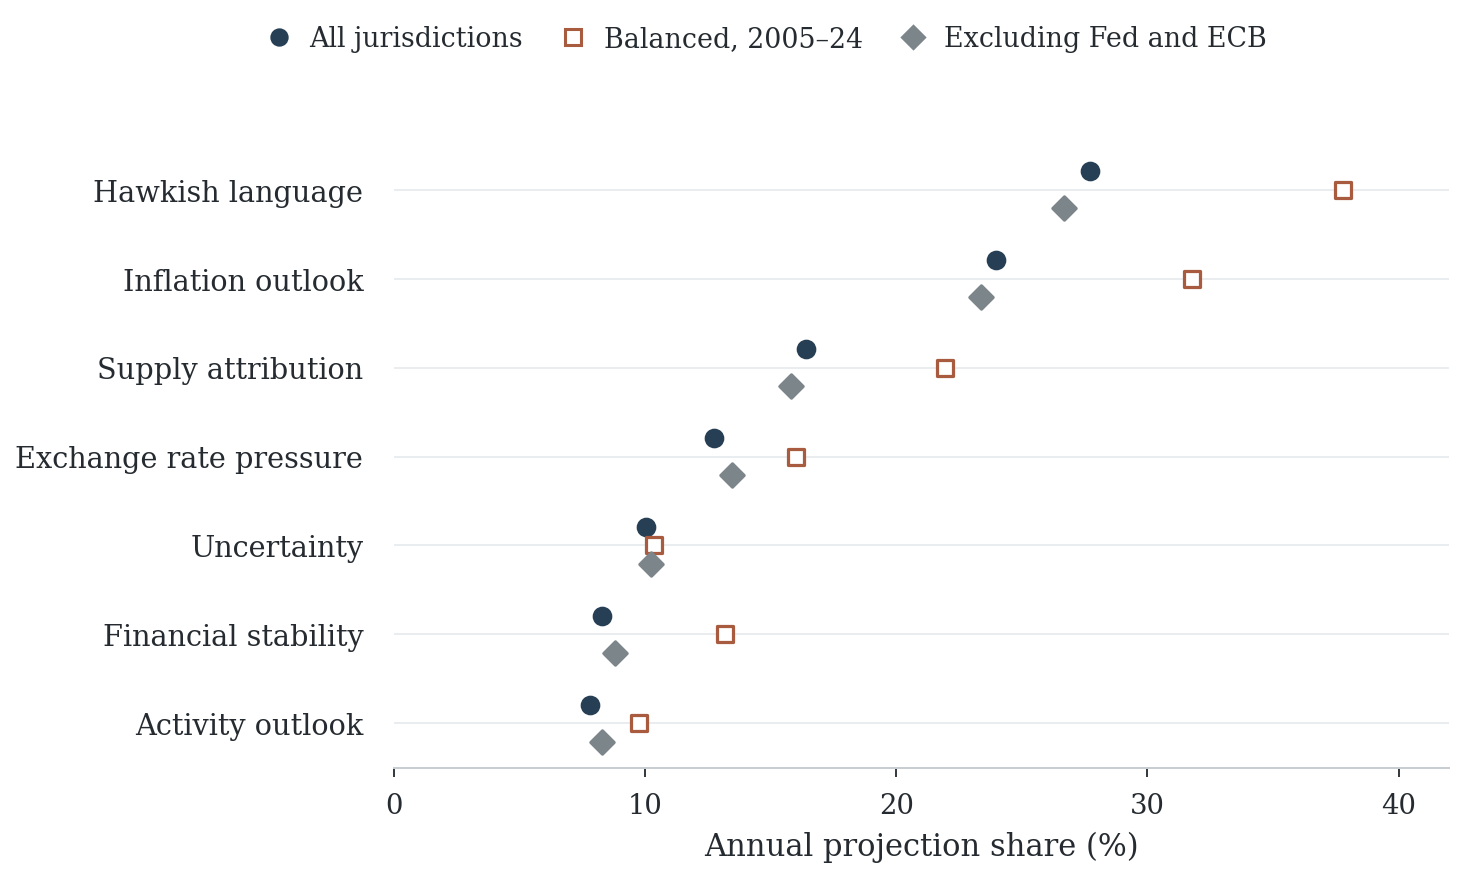

In [12]:
show_figure('figure_annual','Figure_1')

### Figure 2 · Measurement and timing of the design

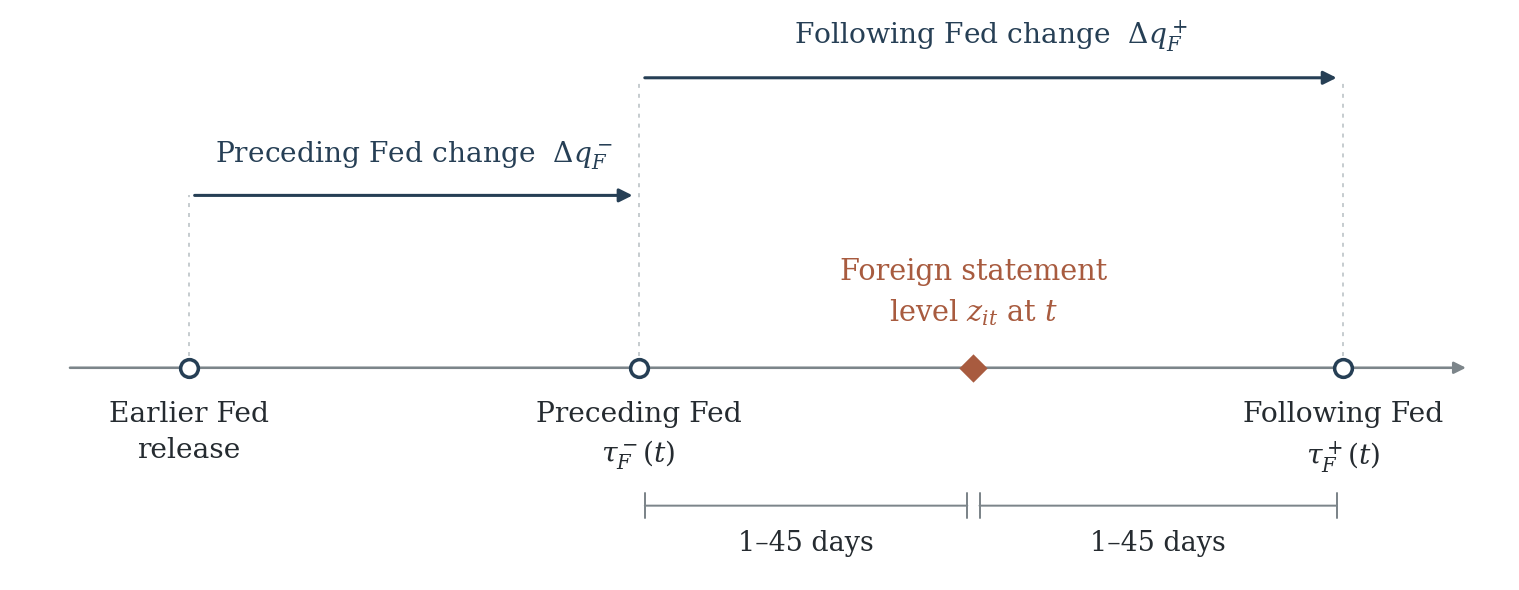

In [13]:
show_figure('timeline','Figure_2')

### Table 1 · Joint timing contrast across measurements
Estimate the four measurements on their eligible samples, with country and year effects, two-way clustered errors, and the stated BH families.

In [14]:
m,primary=a.main_models(d)
show_table('Table_1')

Concept,TF–IDF,Direct LLM,Embeddings,Pairwise leader
Activity outlook,"-0.022 (0.015) q=0.312, n=4,821","0.048 (0.039) q=0.513, n=3,595","0.028 (0.030) q=0.460, n=4,821","0.004 (0.015) q=0.923, n=2,530"
Inflation outlook,"0.024 (0.017) q=0.312, n=4,821","0.088 (0.033) q=0.036, n=3,469","0.049 (0.021) q=0.076, n=4,821","0.033 (0.009) q=0.005, n=2,349"
Hawkish language,"0.010 (0.015) q=0.513, n=4,821","0.014 (0.025) q=0.711, n=3,994","0.067 (0.023) q=0.040, n=4,821","0.005 (0.008) q=0.718, n=2,109"
Supply attribution,"0.019 (0.023) q=0.513, n=4,821","0.020 (0.039) q=0.711, n=1,429","0.042 (0.029) q=0.270, n=4,821","0.033 (0.038) q=0.690, n=974"
Uncertainty,"0.041 (0.016) q=0.038, n=4,821","0.049 (0.018) q=0.036, n=3,205","0.037 (0.025) q=0.270, n=4,821","-0.026 (0.010) q=0.038, n=1,738"
Exchange rate pressure,"-0.012 (0.016) q=0.513, n=4,821",n.a.,"0.011 (0.037) q=0.774, n=4,821",n.a.
Financial stability,"0.039 (0.014) q=0.038, n=4,821","-0.025 (0.042) q=0.711, n=1,081","0.020 (0.023) q=0.460, n=4,821","-0.119 (0.105) q=0.619, n=645"


### Figure 3 · Phrase-timing contrasts
Compute match shares from saved phrase counts and estimate their preceding-minus-following differences. No phrase strings or statement texts are needed.

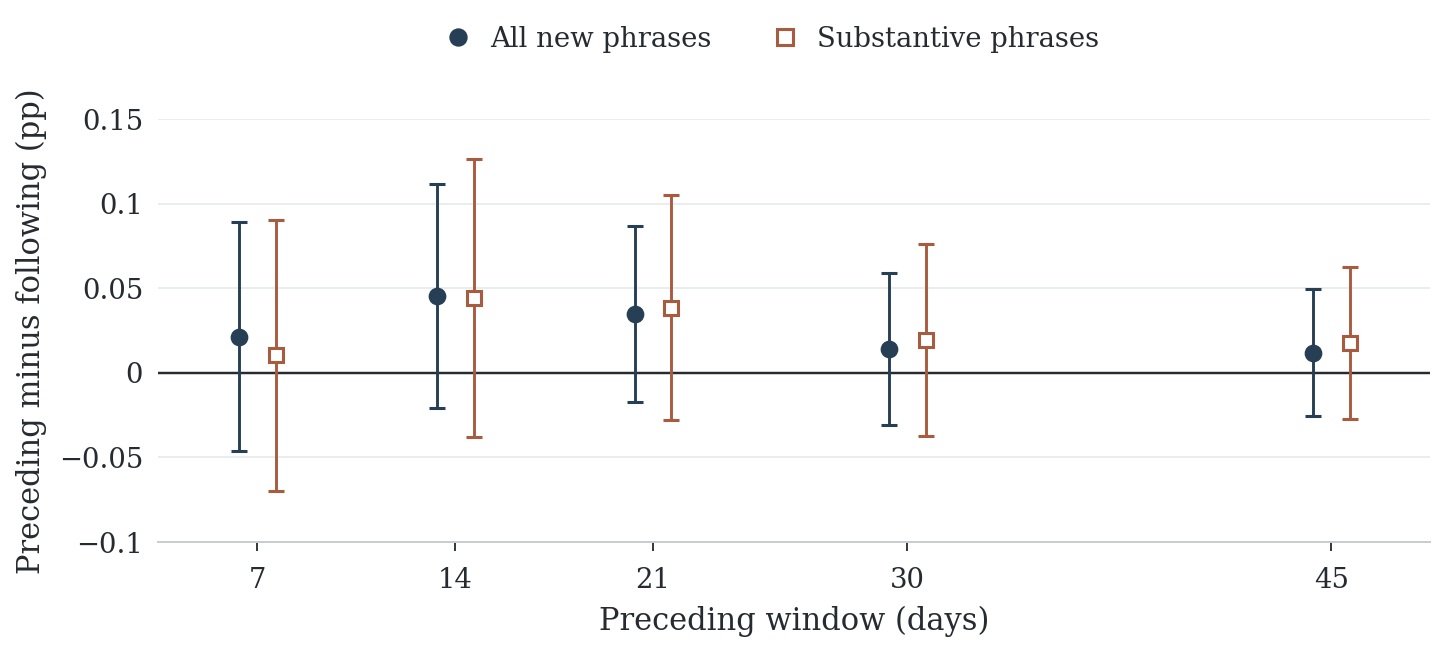

In [15]:
a.phrase_tests(d,m)
show_figure('figure_phrases','Figure_3')

## Online appendix

### Figure A1 · Coverage and document length

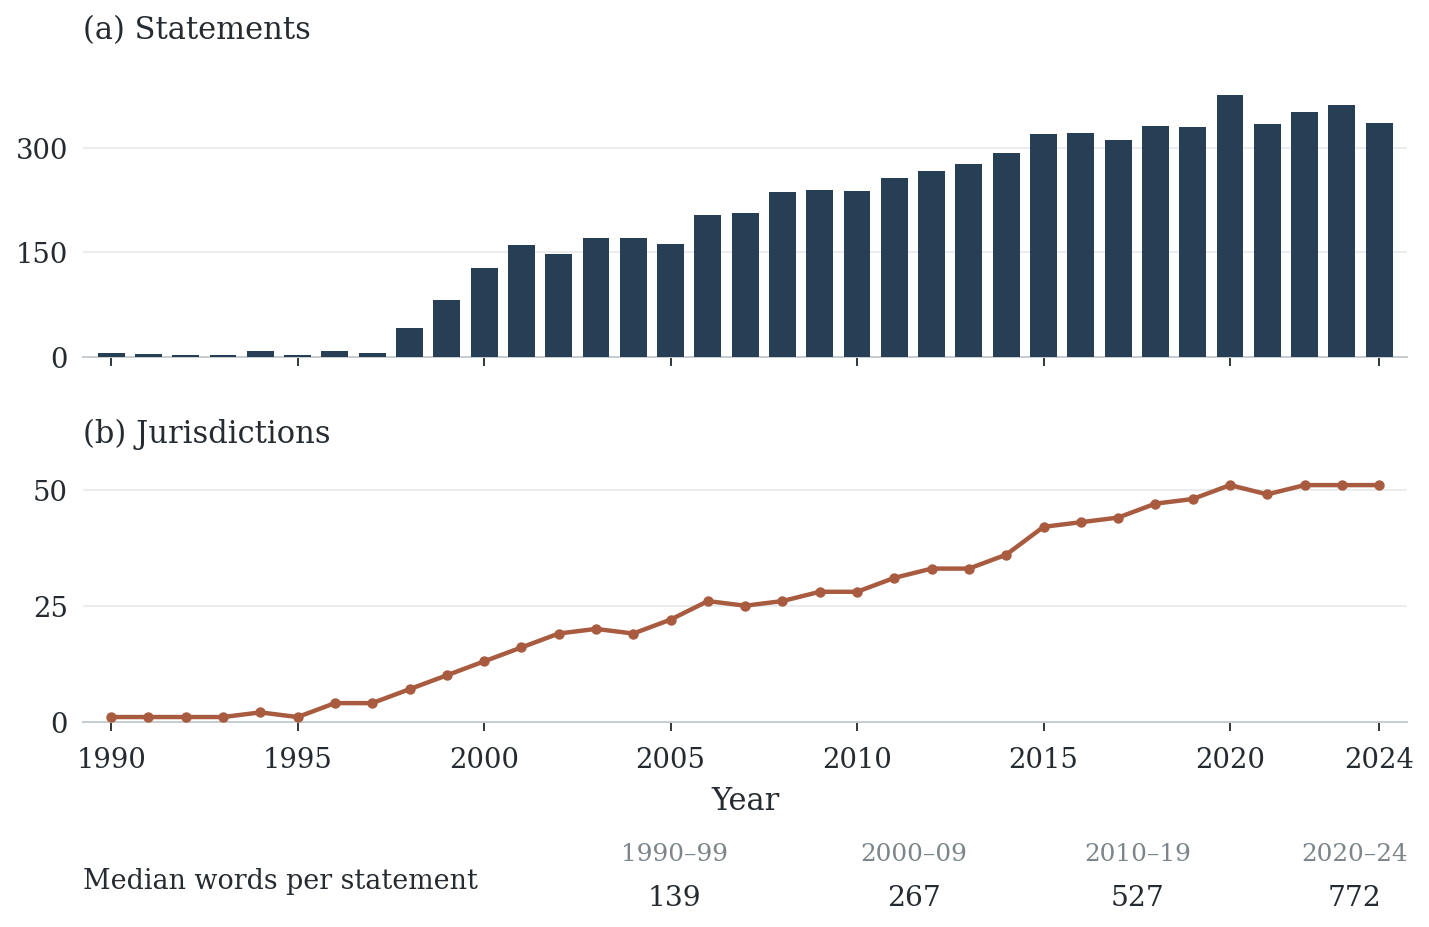

In [16]:
show_figure('figure_coverage_singlepanel','Figure_A1')

### Table A1 · Jurisdiction coverage

In [17]:
show_table('Table_A1')

jurisdiction,statements,first,last,median_words
Argentina,52,2016-08-09,2024-11-01,334.500000
Australia,231,1990-01-23,2024-12-10,528.000000
Brazil,151,2006-03-08,2024-12-11,132.000000
Canada,128,2009-01-20,2024-12-11,506.500000
Chile,274,1998-01-08,2024-09-03,241.500000
Colombia,85,2015-08-21,2024-10-31,355.000000
Czechia,88,2014-02-06,2024-11-07,959.500000
Egypt,155,2005-06-02,2024-11-21,385.000000
Eswatini,59,2011-05-13,2024-11-22,758.000000
Euro area,304,1999-03-04,2024-12-12,63.000000


### Table A2 · Annual lexical projection shares by country group

In [18]:
show_table('Table_A2')

Concept,All,No US/ECB,Advanced,Other,Six-bank core
Activity outlook,7.8,8.3,14.4,9.9,28.2
Inflation outlook,24.0,23.4,31.7,23.5,50.1
Hawkish language,27.7,26.7,37.8,27.8,58.6
Supply attribution,16.4,15.8,24.2,19.4,36.6
Uncertainty,10.0,10.3,15.9,10.4,24.5
Exchange rate pressure,12.7,13.5,17.5,14.5,28.0
Financial stability,8.3,8.8,21.2,11.8,24.6


### Figure A2 · Topic attention with and without fixed country coverage

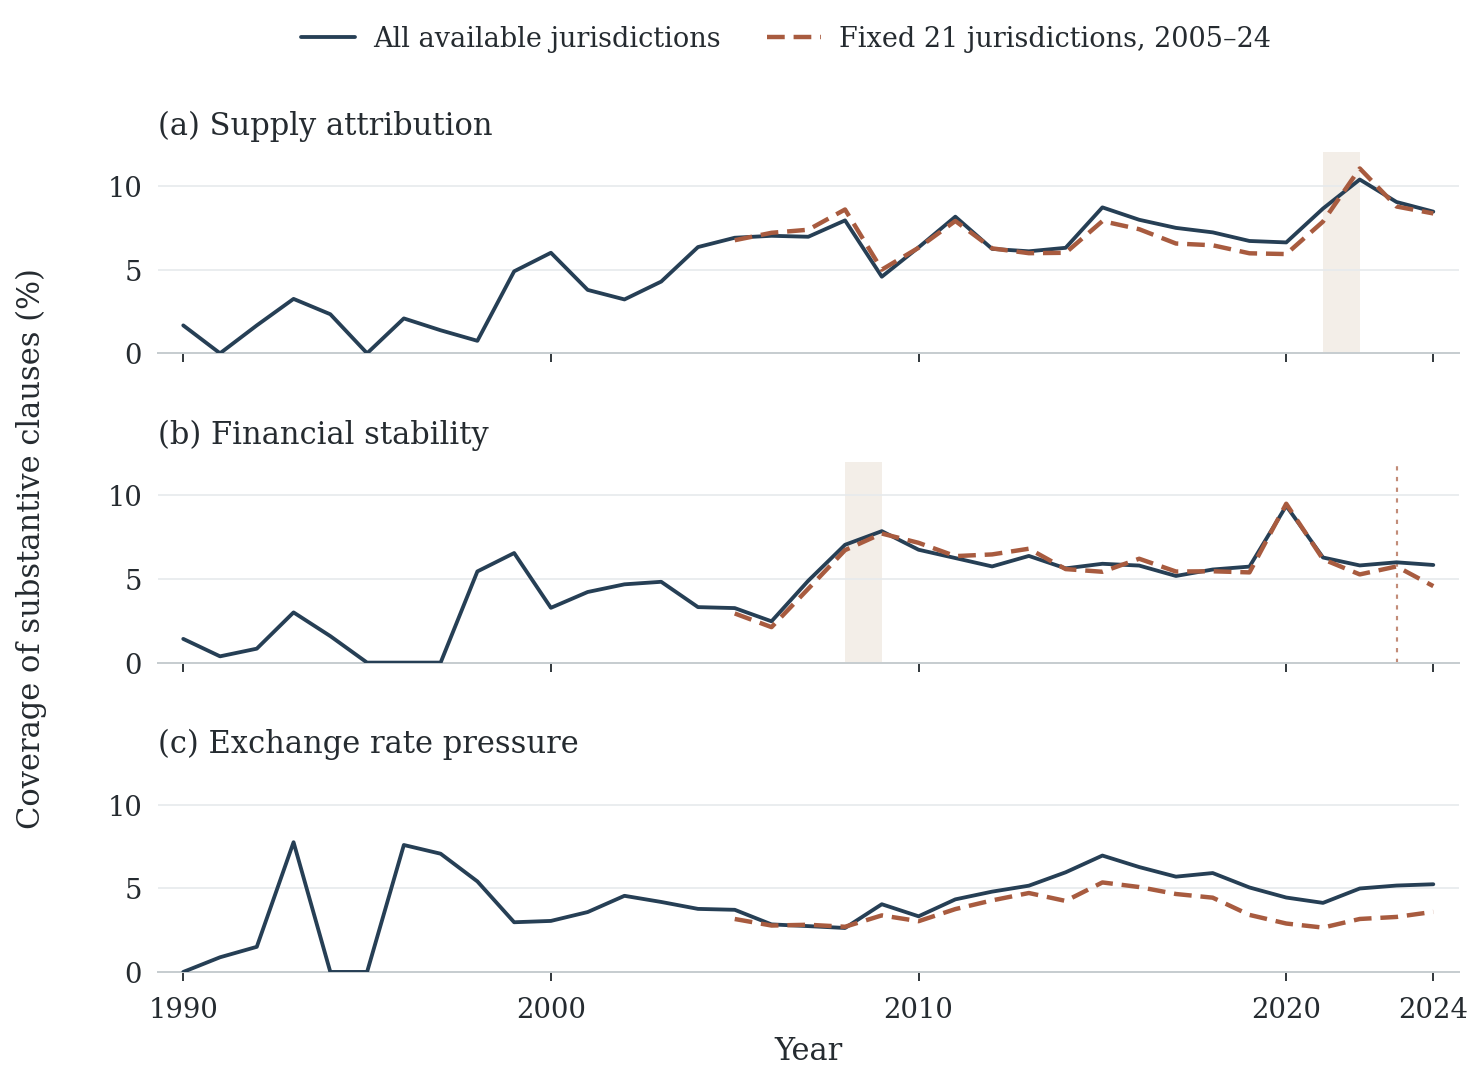

In [19]:
a.reliability(scores,pairs,d)
show_figure('figure_attention','Figure_A2')

### Table A3 · Preceding and following Fed changes, estimated jointly

In [20]:
show_table('Table_A3')

Concept,Preceding,Following,Difference
Activity outlook,-0.037 (0.016),-0.015 (0.013),-0.022 (0.015)
Inflation outlook,0.027 (0.016),0.003 (0.014),0.024 (0.017)
Hawkish language,0.010 (0.011),0.001 (0.018),0.010 (0.015)
Supply attribution,0.038 (0.017),0.019 (0.018),0.019 (0.023)
Uncertainty,0.028 (0.015),-0.013 (0.010),0.041 (0.016)
Exchange rate pressure,0.023 (0.014),0.035 (0.016),-0.012 (0.016)
Financial stability,0.041 (0.016),0.002 (0.026),0.039 (0.014)


### Table A4 · Sensitivity of the lexical timing contrast

In [21]:
show_table('Table_A4')

Concept,No duplicates,Date screen,No 2020–22,Own lag,Equal events
Activity outlook,-0.022 (0.015),-0.021 (0.014),-0.030 (0.016),-0.022 (0.016),-0.019 (0.019)
Inflation outlook,0.025 (0.018),0.025 (0.017),0.008 (0.018),0.000 (0.016),-0.002 (0.020)
Hawkish language,0.010 (0.015),0.010 (0.016),-0.004 (0.012),0.010 (0.017),-0.009 (0.021)
Supply attribution,0.020 (0.023),0.020 (0.023),0.015 (0.021),0.013 (0.024),0.023 (0.026)
Uncertainty,0.041 (0.016),0.036 (0.017),0.033 (0.017),0.038 (0.019),0.040 (0.014)
Exchange rate pressure,-0.012 (0.016),-0.015 (0.016),-0.009 (0.018),-0.024 (0.020),-0.026 (0.025)
Financial stability,0.038 (0.014),0.029 (0.014),0.034 (0.015),0.029 (0.017),0.021 (0.014)


### Table A5 · Hawkish results under different clustering choices

In [22]:
a.clustering_sensitivity()
show_table('Table_A5')

All-method clustering sensitivity complete; raw two-way estimates retained.


Method,Country + Fed,Country only,Fed only,Country + month
TF–IDF,0.010 (0.015),0.010 (0.014),0.010 (0.020),0.010 (0.012)
Direct LLM,0.014 (0.025),0.014 (0.017),0.014 (0.029),0.014 (0.018)
Embeddings,0.067 (0.023),0.067 (0.020),0.067 (0.028),0.067 (0.023)
Pairwise leader,0.005 (0.008),0.005 (0.023),0.005 (0.020),0.005 (0.011)


### Table A6 · A common-news example with zero transmission

In [23]:
import identification
identification.run()
show_table('Table_A6')

 rho  true_transmission  expected_past  expected_future  expected_difference  simulated_past  simulated_future  simulated_difference      n  seed
0.00                  0       0.471405        -0.471405             0.942809        0.471183         -0.471188              0.942371 199999 23019
0.25                  0       0.445362        -0.445362             0.890724        0.445043         -0.445043              0.890086 199999 23019
0.50                  0       0.400000        -0.400000             0.800000        0.398682         -0.398682              0.797364 199999 23019
0.75                  0       0.314270        -0.314270             0.628539        0.314074         -0.314072              0.628146 199999 23019
0.90                  0       0.212959        -0.212959             0.425918        0.212002         -0.211995              0.423997 199999 23019
0.95                  0       0.154257        -0.154257             0.308515        0.154959         -0.155093              

rho,expected_past,expected_future,expected_difference,simulated_difference
0.000000,0.471000,-0.471000,0.943000,0.942000
0.250000,0.445000,-0.445000,0.891000,0.890000
0.500000,0.400000,-0.400000,0.800000,0.797000
0.750000,0.314000,-0.314000,0.629000,0.628000
0.900000,0.213000,-0.213000,0.426000,0.424000
0.950000,0.154000,-0.154000,0.309000,0.310000


### Figure A3 · Phrase contrasts by Fed mention and source language

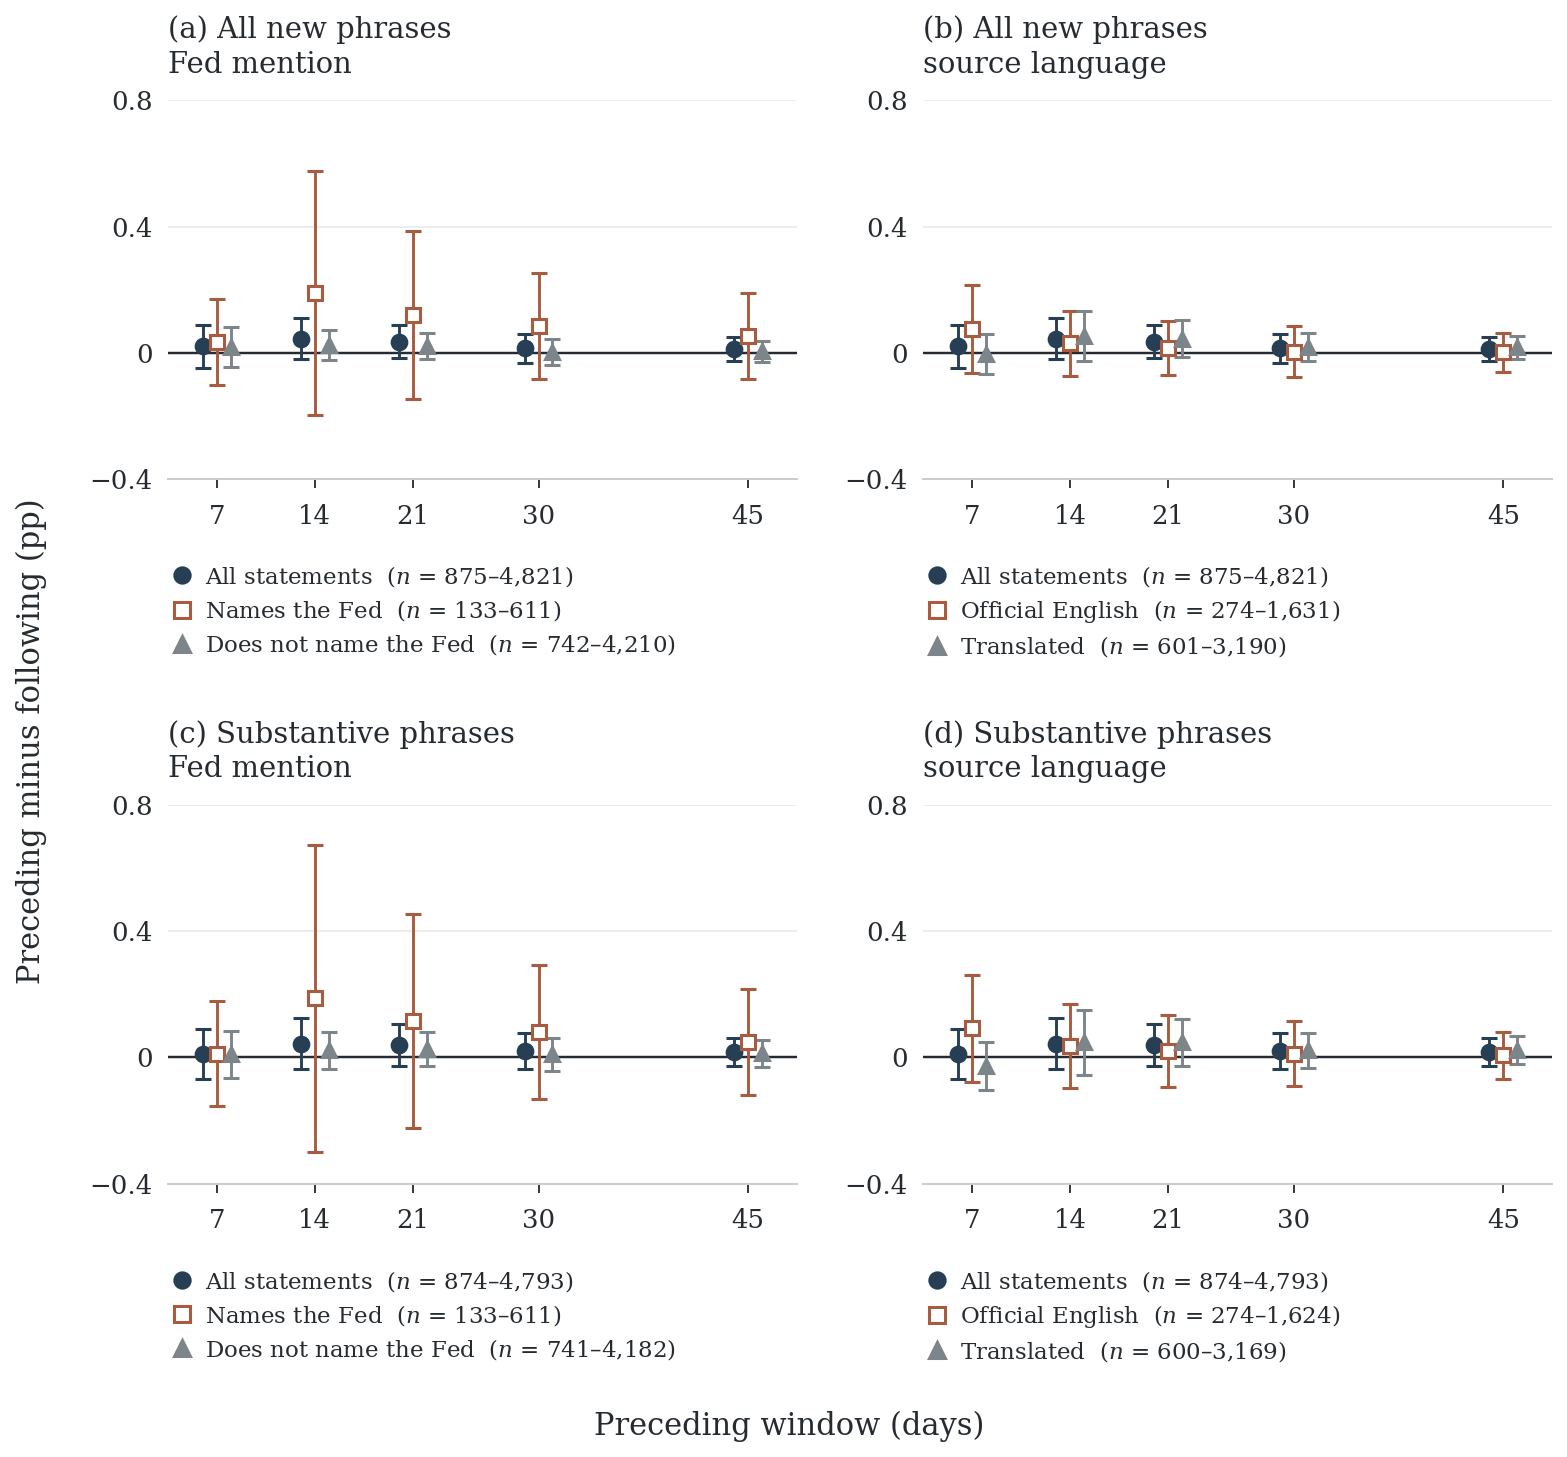

In [24]:
show_figure('figure_phrases_appendix','Figure_A3')

### Table A7 · Directional-claim alignment
Use saved claim categories and evidence-verification flags to identify new Fed claim types, then estimate the timing comparisons.

In [25]:
a.claim_tests(d,m,claims)
show_table('Table_A7')

Draw,Scope,Concept,7 days,14 days,21 days,30 days,45 days
1,domestic,activity,-0.53 (5.29),1.33 (3.94),1.98 (3.98),2.04 (3.57),2.10 (3.39)
1,domestic,inflation,-4.98 (6.76),-3.04 (5.85),-2.28 (5.31),-2.19 (4.93),-1.47 (4.90)
1,US_reporting,activity,-0.24 (1.53),1.14 (1.21),0.86 (1.02),0.44 (0.82),0.16 (0.67)
1,US_reporting,inflation,-0.45 (0.44),-0.57 (0.56),-0.33 (0.40),0.17 (0.51),0.08 (0.47)
2,domestic,activity,-3.69 (5.63),-2.26 (4.37),-1.57 (4.27),-1.36 (3.93),-1.74 (3.87)
2,domestic,inflation,0.64 (6.77),3.58 (5.04),1.90 (4.43),-0.80 (3.81),0.48 (3.67)
2,US_reporting,activity,1.72 (1.50),1.65 (1.07),0.74 (0.87),0.64 (0.67),0.48 (0.66)
2,US_reporting,inflation,0.24 (0.74),0.57 (0.58),0.38 (0.35),0.23 (0.23),-0.01 (0.15)


### Table A8 · Repeatability of ratings

In [26]:
show_table('Table_A8')

Concept,Level n,Level r,Level MAE,Fed pair n,Pair r,Pair MAE
Activity outlook,5404,0.968000,3.103000,159,0.855000,5.673000
Inflation outlook,5535,0.936000,3.382000,148,0.864000,4.203000
Hawkish language,5848,0.971000,3.291000,153,0.918000,4.333000
Supply attribution,4549,0.644000,8.098000,70,0.829000,4.157000
Uncertainty,5560,0.877000,3.461000,111,0.738000,4.604000
Exchange rate pressure,3594,0.473000,13.191000,0,nan,nan
Financial stability,3811,0.670000,6.653000,48,0.191000,8.396000


### Table A9 · Differences between Fed measurement methods

In [27]:
a.coefficient_differences()
show_table('Table_A9')

Concept,Lexical minus LLM,Lexical minus embeddings,Lexical minus pair
Activity outlook,0.006 (0.026),-0.005 (0.024),-0.013 (0.021)
Inflation outlook,-0.001 (0.022),0.013 (0.033),-0.014 (0.024)
Hawkish language,-0.005 (0.017),0.014 (0.011),0.013 (0.017)
Supply attribution,0.001 (0.038),0.034 (0.036),-0.001 (0.029)
Uncertainty,0.012 (0.016),0.015 (0.027),0.015 (0.019)
Exchange rate pressure,n.a.,n.a.,n.a.
Financial stability,0.010 (0.025),0.073 (0.040),0.003 (0.025)


### Table A10 · Reconstruction diagnostics

In [28]:
a.reconstruction()
show_table('Table_A10')

concept,score_pairs,mae,absence_agreement,10,50,90
Activity outlook,278,5.300000,99.700000,12.500000,50.000000,85.000000
Financial stability,206,17.700000,99.000000,87.500000,67.500000,87.500000
Exchange rate pressure,222,14.300000,99.300000,12.500000,67.500000,92.500000
Hawkish language,300,5.900000,100.000000,15.000000,50.000000,90.000000
Inflation outlook,294,6.300000,99.700000,20.000000,50.000000,85.000000
Supply attribution,254,12.200000,99.300000,82.500000,62.500000,90.000000
Uncertainty,287,8.700000,95.800000,15.000000,87.500000,90.000000


## Save the exhibits
Only the eleven table CSVs and six figure PDFs are written to `results/`. Intermediate files stay in a temporary workspace.

In [29]:
import verification
verification.run()
assert len(TABLES)==11 and len(FIGURES)==6
out=PACKAGE/'results';out.mkdir(exist_ok=True)
for name,frame in TABLES.items():frame.to_csv(out/f'{name}.csv',index=False)
for name,path in FIGURES.items():shutil.copy2(path,out/f'{name}.pdf')
os.chdir(PACKAGE)
print('Done. Saved 11 tables and 6 figures in results/.')


Statistical checks passed.
Done. Saved 11 tables and 6 figures in results/.
